# Model Decision Tree

## 3.4. Drzewa decyzyjne (Decision Tree)

Drzewa decyzyjne należą do grupy modeli uczenia nadzorowanego, które podejmują decyzje poprzez
rekurencyjne dzielenie przestrzeni cech na coraz mniejsze podzbiory.  
Model przyjmuje postać struktury drzewa, gdzie:

- **węzły wewnętrzne (ang. internal nodes)** reprezentują test na jednej ze zmiennych,
  np. *Prob_H_b365 > 0.45?*
- **gałęzie (ang. branches)** odpowiadają wynikom testu,
- **liście (ang. leaves)** zawierają finalną predykcję modelu (np. jedną z klas: *H*, *D*, *A*).

### 3.4.1. Algorytm budowania drzewa

Budowa drzewa polega na iteracyjnym wyszukiwaniu takiego podziału danych (cecha + próg),
który **maksymalizuje czystość klas** w powstałych gałęziach.  
Najpopularniejsze funkcje oceny czystości to:

#### • Indeks Giniego

\[
Gini = 1 - \sum_{k=1}^{K} p_k^2
\]

gdzie \(p_k\) jest udziałem klasy \(k\) w danym węźle.

#### • Entropia

\[
Entropy = - \sum_{k=1}^{K} p_k \log_2 (p_k)
\]

Im niższa wartość miary, tym bardziej jednorodny węzeł (czyli lepszy podział).

### 3.4.2. Zalety drzew decyzyjnych

Drzewa decyzyjne są chętnie stosowane ze względu na:

- **brak wymogu skalowania cech**,  
- **obsługę nieliniowości** oraz interakcji pomiędzy zmiennymi,
- **intuicyjną interpretowalność** (możliwość wizualizacji struktury drzewa),
- możliwość ustalania wag klas.

Cechy te czynią drzewa atrakcyjnym modelem bazowym przy klasyfikacji wyników sportowych,
gdzie zależności między zmiennymi mogą być bardzo nieliniowe.

### 3.4.3. Wady drzew decyzyjnych

Główną słabością drzew decyzyjnych jest **wysoka podatność na przeuczenie** (overfitting).  
Drzewo niekontrolowane (bez limitu głębokości) może praktycznie „zapamiętać” dane uczące.

Dlatego konieczne jest zastosowanie tzw. *przycinania* drzewa poprzez dobranie hiperparametrów takich jak:

- `max_depth` – maksymalna głębokość drzewa,  
- `min_samples_split` – minimalna liczba próbek do podziału węzła,  
- `min_samples_leaf` – minimalna liczba próbek w liściu,  
- `class_weight` – regulacja wpływu częstości klas.

Dobór tych parametrów odbywa się zwykle metodą wyszukiwania siatką (GridSearchCV).

### 3.4.4. Zastosowanie w analizie wyników meczów

W niniejszej pracy drzewo decyzyjne wykorzystane zostało jako model klasyfikacyjny
przewidujący rezultat meczu piłkarskiego spośród trzech klas:

- **H** – zwycięstwo gospodarzy,
- **D** – remis,
- **A** – zwycięstwo gości.

Model trenowany jest na tych samych cechach, które wykorzystano przy regresji logistycznej,
co umożliwia uczciwe porównanie jakości obu podejść — modeli liniowych i nieliniowych.
Drzewo potrafi uchwycić złożone interakcje między cechami (np. między kursami bukmacherskimi,
formą z ostatnich meczów czy różnicą jakości drużyn), co czyni je dobrym uzupełnieniem
bardziej klasycznych metod statystycznych.



Przygotowanie danych

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

LEAGUE = "premier_league"
# LEAGUE = "serie_a"
# LEAGUE = "la_liga"
# LEAGUE = "bundesliga"
#LEAGUE = "ligue_1"
# LEAGUE = "all_leagues"

EXPERIMENT = "decision_tree"

DATA_DIR = Path("../data/processed")

DATA_PATH = DATA_DIR / LEAGUE / f"{LEAGUE}_features.csv"

RESULTS_DIR = Path(f"../results/{LEAGUE}/{EXPERIMENT}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("LEAGUE:", LEAGUE)
print("DATA_PATH:", DATA_PATH)
print("RESULTS_DIR:", RESULTS_DIR)

LEAGUES_DICT = {
    "premier_league": "Premier League",
    "serie_a": "Serie A",
    "la_liga": "La Liga",
    "bundesliga": "Bundesliga",
    "ligue_1": "Ligue 1",
    "all_leagues": "All Leagues"
}

current_league_name = LEAGUES_DICT[LEAGUE]

LEAGUE: premier_league
DATA_PATH: ..\data\processed\premier_league\premier_league_features.csv
RESULTS_DIR: ..\results\premier_league\decision_tree


In [2]:
def save_plot(filename, dpi=150):
    plt.savefig(
        RESULTS_DIR / filename,
        dpi=dpi,
        bbox_inches="tight"
    )

def save_df(df, filename):
    df.to_csv(
        RESULTS_DIR / filename,
        index=False
    )

def close_plot():
    plt.close()



def plot_and_save_class_distribution(
    y_true_cls,
    y_pred_cls,
    option_suffix,     
    filename_prefix     
):
    """
    y_true_cls : lista klas ["H","D","A"] lub ["0","1"] itp.
    y_pred_cls : lista klas
    """

    df_counts = (
        pd.DataFrame({
            "True": y_true_cls,
            "Pred": y_pred_cls
        })
        .melt(var_name="Type", value_name="Class")
        .value_counts()
        .reset_index(name="Count")
    )

    df_true = df_counts[df_counts["Type"] == "True"][["Class","Count"]] \
        .rename(columns={"Count":"True_Count"})
    df_pred = df_counts[df_counts["Type"] == "Pred"][["Class","Count"]] \
        .rename(columns={"Count":"Pred_Count"})

    df_final = (
        pd.merge(df_true, df_pred, on="Class", how="outer")
        .fillna(0)
        .sort_values("Class")
    )


    save_df(
        df_final,
        f"{filename_prefix}_{option_suffix}.csv"
    )

    x = np.arange(len(df_final))
    width = 0.35

    plt.figure(figsize=(8,5))
    plt.bar(x - width/2, df_final["True_Count"], width, label="True")
    plt.bar(x + width/2, df_final["Pred_Count"], width, label="Pred")

    plt.xticks(x, df_final["Class"])
    plt.ylabel("Liczba meczów")
    plt.title(f"Rozkład klas — {option_suffix}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    save_plot(f"{filename_prefix}_{option_suffix}.png")
    plt.show()
    close_plot()

    return df_final

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values(["Date", "HomeTeam", "AwayTeam"]).reset_index(drop=True)
print(df.shape)
df.head(3)

(3420, 113)


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,...,FormDiff_AttDefRatio_last5,FormDiff_GoalsShare_last5,Home_RecentFormIdx,Away_RecentFormIdx,FormDiff_RecentFormIdx,Market_ImpliedDiff_b365,Market_ImpliedDiff_ps,Market_BigHomeFav,Market_BigAwayFav,Market_BalancedMatch
0,E0,2014-08-16,Arsenal,Crystal Palace,2.0,1.0,H,14.0,4.0,6.0,...,NaN,NaN,NaN,NaN,NaN,0.718593,0.708064,1,0,0
1,E0,2014-08-16,Leicester,Everton,2.0,2.0,D,11.0,13.0,3.0,...,NaN,NaN,NaN,NaN,NaN,-0.101796,-0.086236,0,0,0
2,E0,2014-08-16,Manchester United,Swansea,1.0,2.0,A,14.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,0.627931,0.622914,1,0,0


In [4]:
# cols_to_exclude = {
#     # meta / identyfikatory
#     "Div", "Date", "Season", "SourceFile", "HomeTeam", "AwayTeam", "Referee",

#     # wynikowe i bieżące statystyki meczu (niedostępne przed meczem)
#     "FTHG", "FTAG", "HTHG", "HTAG", "FTR",
#     "GoalDiff", "TotalGoals",
#     "HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC",
#     "HY", "AY", "HR", "AR",

#     # NOWE — usuwamy nadmiarowe prawdopodobieństwa, które psują regresję
#     "Prob_D_b365", "Prob_A_b365"
# }

In [5]:
target = "FTR"
cols_to_exclude = {
    # meta / identyfikatory
    "Div", "Date", "Season", "SourceFile", "HomeTeam", "AwayTeam", "Referee",

    # wynik meczu – niedostępne przed spotkaniem
    "FTHG", "FTAG", "HTHG", "HTAG", "FTR",
    "GoalDiff", "TotalGoals",
    "HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC",
    "HY", "AY", "HR", "AR",

    # bukmacher – nadmiarowe prawdopodobieństwa i miary
    "Prob_D_b365", "Prob_A_b365",
    "Prob_H_ps", "Prob_D_ps", "Prob_A_ps",
    "Margin_B365", "Margin_PS",
    "OddsDiff_B365", "OddsDiff_PS",
    "OddsSpread_H", "OddsSpread_D", "OddsSpread_A",

    # forma gospodarzy – duplikaty lub mało stabilne
    "Home_Wins_last5",
    "Home_CleanSheets_last5",
    "Home_Conceded0plus_last5",
    "Home_GD_last3",
    "Home_Pts_last3",
    "Home_GD_last10",         # silna korelacja z Pts_last10
    "Home_AvgGD_season",

    # forma gości – duplikaty lub mało stabilne
    "Away_Wins_last5",
    "Away_CleanSheets_last5",
    "Away_Conceded0plus_last5",
    "Away_GD_last3",
    "Away_Pts_last3",
    "Away_GD_last10",         # silna korelacja z Pts_last10
    "Away_AvgGD_season",

    # FormDiff – różnice formy (duplikaty)
    "FormDiff_Wins_last5",
    "FormDiff_CleanSheets_last5",
    "FormDiff_Conceded0plus_last5",
    "FormDiff_GD_last3",
    "FormDiff_Pts_last3",
    "FormDiff_GD_last10",
    "FormDiff_Pts_last10",

    # kalendarz – duplikat Weekday
    "IsWeekend",

    # siła sezonu – duplikat PtsDiff
    "SeasonStrength_GDDiff",
}


candidate_cols = [c for c in df.columns if c not in cols_to_exclude]

keep_patterns = (
    "Prob_", "Margin_", "OddsDiff", "OddsSpread",
    "Home_", "Away_", "FormDiff_", "Pts_trend_3v10",
    "SeasonStrength_", "Month", "Weekday", "IsWeekend",# "Market_"  # ew zakomentowac Market 
)

X_features = [c for c in candidate_cols if any(p in c for p in keep_patterns)]


print(f"Liczba wybranych cech: {len(X_features)}")

Liczba wybranych cech: 32


In [6]:
from sklearn.preprocessing import LabelEncoder


# Label encoding: A/D/H -> 0/1/2 (kolejność zależy od LabelEncoder)
le_dt = LabelEncoder()
y_clf_dt = le_dt.fit_transform(df[target])


X_clf_dt = df[X_features].copy()

# Podział czasowy jak wcześniej

split_date = pd.Timestamp("2022-07-01")
train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date

X_train_dt = X_clf_dt.loc[train_mask].reset_index(drop=True)
X_test_dt  = X_clf_dt.loc[test_mask].reset_index(drop=True)
y_train_dt = y_clf_dt[train_mask]
y_test_dt  = y_clf_dt[test_mask]

X_train_dt.shape, X_test_dt.shape, len(y_train_dt), len(y_test_dt)

((2660, 32), (760, 32), 2660, 760)

Model bazowy drzewa + pipeline

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


dt_base = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=0
)
pipe_dt = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", dt_base)
])

GridSearchCV – strojenie hiperparametrów

In [8]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    "model__max_depth": [4, 6, 8, 10, 12, 15, 20, None],
    "model__min_samples_split": [2, 5, 10, 20, 50, 100],
    "model__min_samples_leaf": [1, 2, 5, 10, 20, 50],
    "model__max_features": ["sqrt", "log2", None],
    "model__criterion": ["gini", "entropy"]
}
grid_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

print("Trenowanie GridSearchCV (DecisionTree)...")
grid_dt.fit(X_train_dt, y_train_dt)

print("Najlepsze parametry:", grid_dt.best_params_)
print("Najlepszy wynik CV (Macro-F1):", grid_dt.best_score_)

Trenowanie GridSearchCV (DecisionTree)...
Fitting 5 folds for each of 1728 candidates, totalling 8640 fits
Najlepsze parametry: {'model__criterion': 'entropy', 'model__max_depth': 4, 'model__max_features': None, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Najlepszy wynik CV (Macro-F1): 0.4817965333162473


Ewaluacja na zbiorze testowym


=== Decision Tree (multiclass H/D/A) — TEST ===
Accuracy:  0.5184
Macro-F1:  0.4958

=== Classification report (Decision Tree) ===
              precision    recall  f1-score   support

           A       0.54      0.55      0.54       232
           D       0.27      0.38      0.32       169
           H       0.71      0.56      0.63       359

    accuracy                           0.52       760
   macro avg       0.51      0.50      0.50       760
weighted avg       0.56      0.52      0.53       760



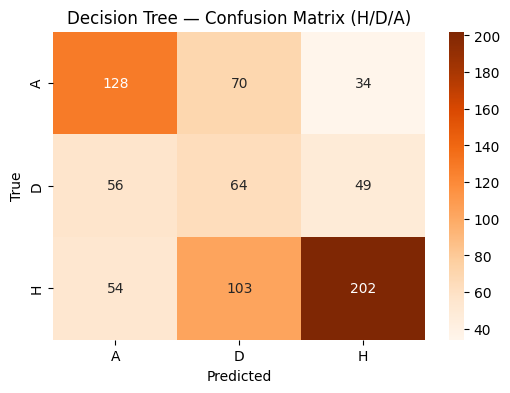

In [9]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.calibration import CalibratedClassifierCV
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_dt)

acc_dt = accuracy_score(y_test_dt, y_pred_dt)
f1_dt  = f1_score(y_test_dt, y_pred_dt, average="macro")


calibrated_dt = CalibratedClassifierCV(
    best_dt,
    method="isotonic",   # albo "sigmoid"
    cv=5
)

calibrated_dt.fit(X_train_dt, y_train_dt)



print("\n=== Decision Tree (multiclass H/D/A) — TEST ===")
print(f"Accuracy:  {acc_dt:.4f}")
print(f"Macro-F1:  {f1_dt:.4f}")

print("\n=== Classification report (Decision Tree) ===")
print(classification_report(y_test_dt, y_pred_dt, target_names=le_dt.classes_))


cm_dt = confusion_matrix(y_test_dt, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt=".0f",
    cmap="Oranges",
    xticklabels=le_dt.classes_,
    yticklabels=le_dt.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Decision Tree — Confusion Matrix (H/D/A)")
save_plot("decision_tree_confusion_matrix.png")
plt.show()
close_plot()

### Kalibracja modelu Decision Tree

Model drzewa decyzyjnego został najpierw wytrenowany i dobrany pod kątem **jakości klasyfikacji (Macro-F1)** przy użyciu `GridSearchCV`.  
Następnie najlepszy model (`best_dt`) został **skalibrowany metodą isotonic**, aby poprawić jakość **przewidywanych prawdopodobieństw**, bez zmiany samych predykcji klas.

Metryki takie jak **Accuracy, Macro-F1 oraz macierz pomyłek** raportowane są dla modelu bazowego (nieskalibrowanego), natomiast **analizy probabilistyczne** (krzywe kalibracyjne) wykonywane są na modelu skalibrowanym.  



In [10]:

# ZAPIS WYNIKÓW

results_dt = pd.DataFrame([{
    "Model": "Decision Tree (Multiclass)",
    "Accuracy": acc_dt,
    "Macro-F1": f1_dt,
    "League": LEAGUE,
    "SplitDate": split_date,
    "N_train": len(y_train_dt),
    "N_test": len(y_test_dt)
}])

save_df(results_dt, "decision_tree_results.csv")
display(results_dt)


,Model,Accuracy,Macro-F1,League,SplitDate,N_train,N_test
0,Decision Tree (Multiclass),0.518421,0.49576,premier_league,2022-07-01,2660,760


In [11]:
report_dt = classification_report(
    y_test_dt,
    y_pred_dt,
    target_names=le_dt.classes_,
    output_dict=True
)

df_report_dt = pd.DataFrame(report_dt).T
df_report_dt["Model"] = "Decision Tree"
df_report_dt["League"] = LEAGUE

save_df(df_report_dt, "decision_tree_classification_report.csv")
display(df_report_dt)

,precision,recall,f1-score,support,Model,League
A,0.537815,0.551724,0.544681,232.000000,Decision Tree,premier_league
D,0.270042,0.378698,0.315271,169.000000,Decision Tree,premier_league
H,0.708772,0.562674,0.627329,359.000000,Decision Tree,premier_league
accuracy,0.518421,0.518421,0.518421,0.518421,Decision Tree,premier_league
macro avg,0.505543,0.497699,0.495760,760.000000,Decision Tree,premier_league
weighted avg,0.559025,0.518421,0.532708,760.000000,Decision Tree,premier_league


C:\Users\tdroz\AppData\Local\Temp\ipykernel_328\1948305656.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


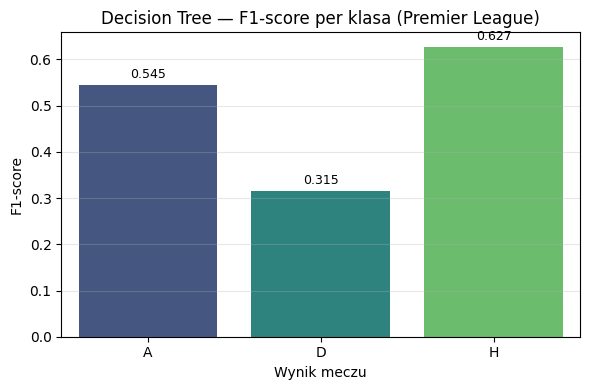

In [12]:
df_f1_class = (
    df_report_dt
    .loc[le_dt.classes_, ["f1-score"]]
    .reset_index()
    .rename(columns={"index": "Outcome"})
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_f1_class,
    x="Outcome",
    y="f1-score",
    palette="viridis"
)

# wartości nad słupkami
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title(f"Decision Tree — F1-score per klasa ({current_league_name})")
plt.xlabel("Wynik meczu")
plt.ylabel("F1-score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Wykres ważności cech (feature importance)

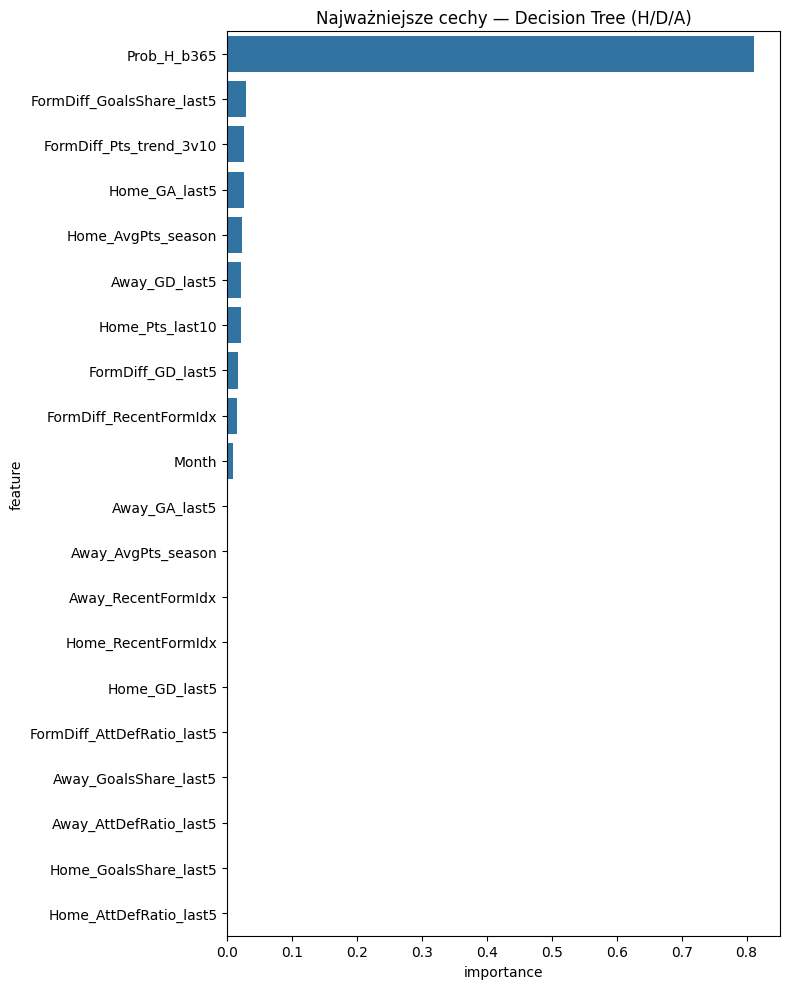

In [13]:
# Pobranie ważności cech z modelu w pipeline
dt_model = best_dt.named_steps["model"]
importances = dt_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train_dt.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp["Model"] = "Decision Tree"
feat_imp["League"] = LEAGUE


# Top 20 cech
top_n = 20
feat_imp_top = feat_imp.head(top_n)

plt.figure(figsize=(8, 0.4*top_n + 2))
sns.barplot(data=feat_imp_top, x="importance", y="feature")
plt.title("Najważniejsze cechy — Decision Tree (H/D/A)")
plt.tight_layout()
save_df(feat_imp, "decision_tree_feature_importance.csv")
save_plot("decision_tree_feature_importance.png")
plt.show()
close_plot()

Learning curve (czy drzewo się przeucza?)

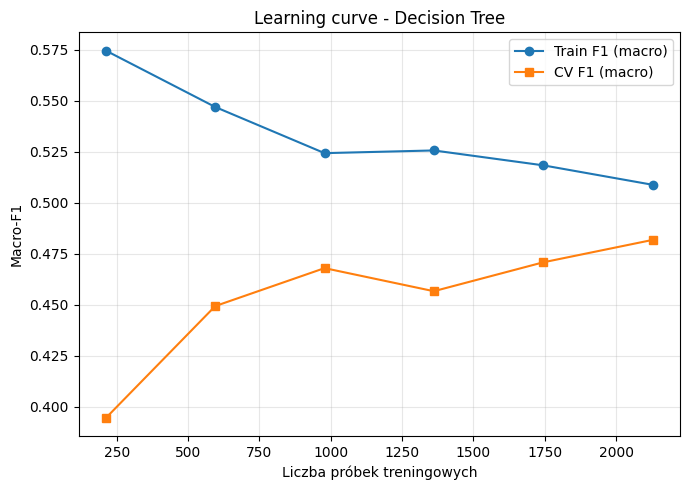

,TrainSize,Train_F1_macro,CV_F1_macro
0,212,0.574505,0.394596
1,595,0.546909,0.449373
2,978,0.524305,0.467968
3,1361,0.525627,0.456656
4,1744,0.518344,0.470794
5,2128,0.508795,0.481797


In [14]:
from sklearn.model_selection import learning_curve


train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_dt,
    X=X_train_dt,
    y=y_train_dt,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker="o", label="Train F1 (macro)")
plt.plot(train_sizes, val_mean, marker="s", label="CV F1 (macro)")
plt.xlabel("Liczba próbek treningowych")
plt.ylabel("Macro-F1")
plt.title("Learning curve - Decision Tree")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
save_plot("decision_tree_learning_curve.png")
plt.show()
close_plot()


lc_df = pd.DataFrame({
    "TrainSize": train_sizes,
    "Train_F1_macro": train_mean,
    "CV_F1_macro": val_mean
})

display(lc_df)

save_df(lc_df, "decision_tree_learning_curve_values.csv")


Wizualizacja drzewa (pierwsze kilka poziomów)

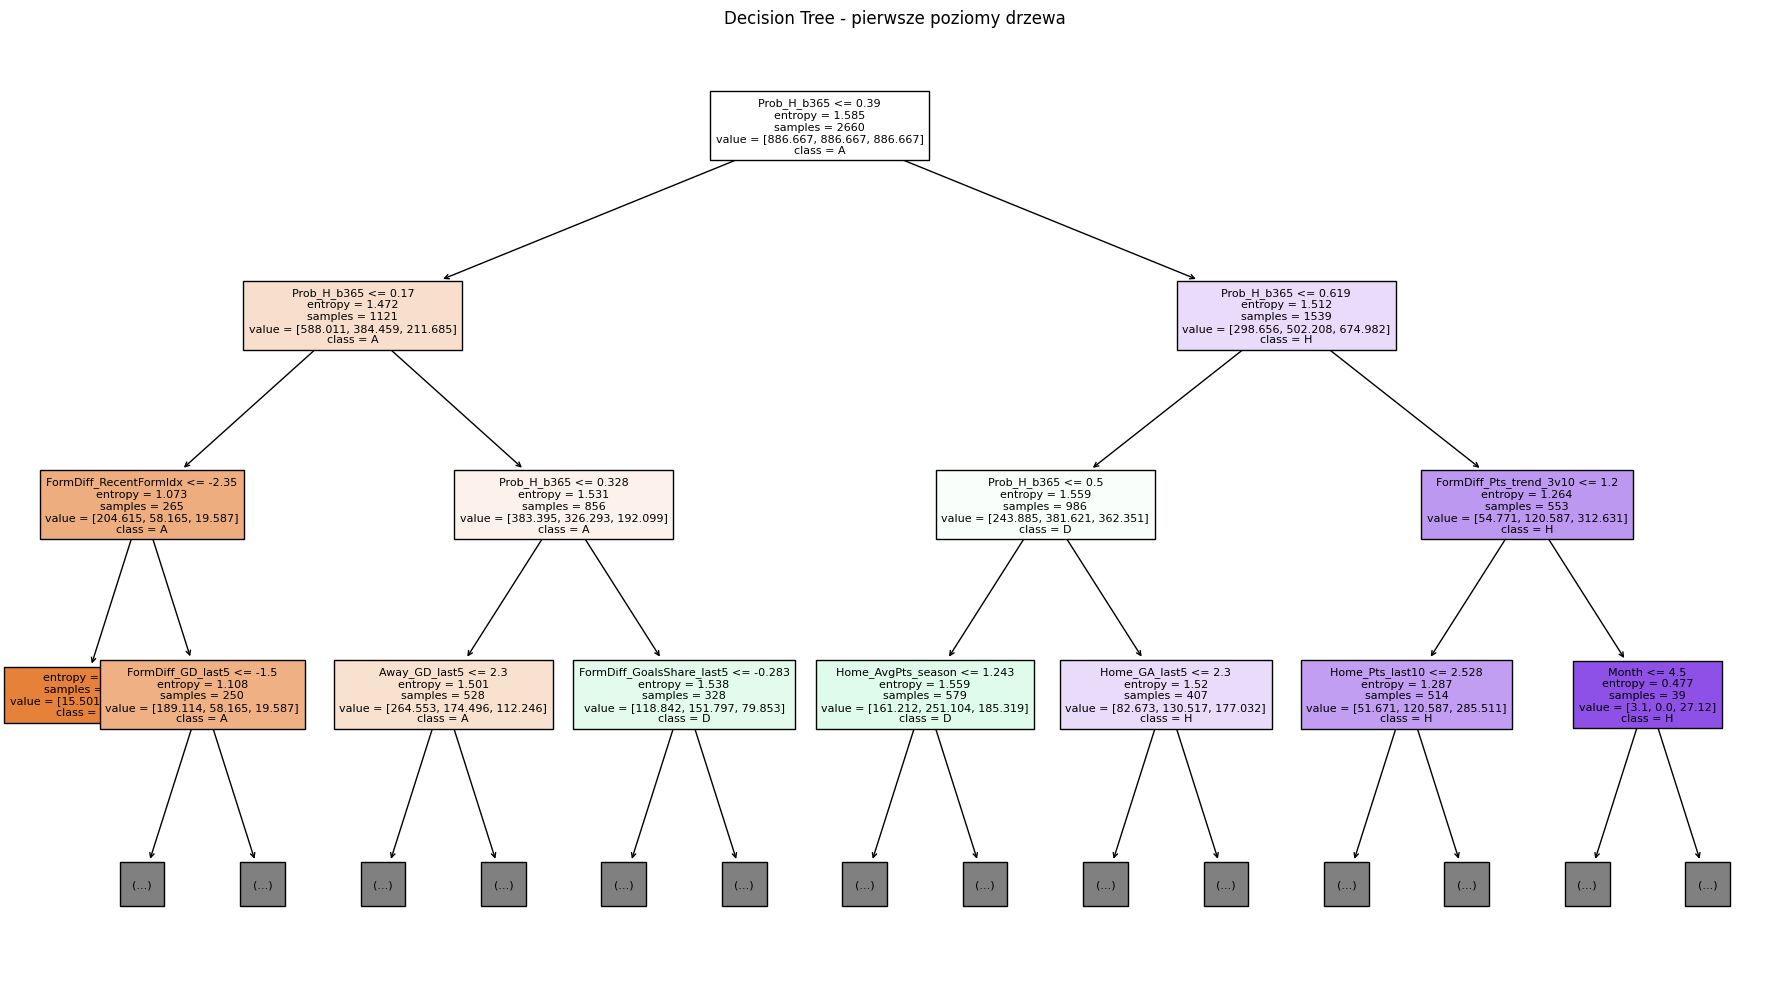

In [15]:
from sklearn.tree import plot_tree


plt.figure(figsize=(18,10))
plot_tree(
    dt_model,
    feature_names=X_train_dt.columns,
    class_names=le_dt.classes_,
    filled=True,
    max_depth=3, 
    fontsize=8
)
plt.title("Decision Tree - pierwsze poziomy drzewa")
plt.tight_layout()
save_plot("decision_tree_structure_depth3.png")
plt.show()
close_plot()


Krzywa kalibracji (czy prawdopodobieństwa są sensowne?)

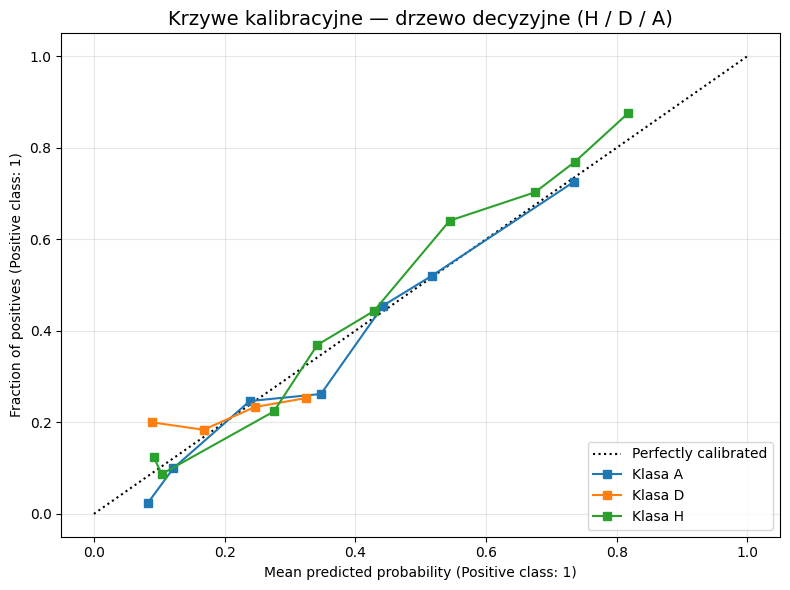

In [16]:
from sklearn.calibration import CalibrationDisplay

calibration_rows = []

y_proba_dt = calibrated_dt.predict_proba(X_test_dt)

fig, ax = plt.subplots(figsize=(8, 6))   

for i, cls in enumerate(le_dt.classes_):
    disp = CalibrationDisplay.from_predictions(
        (y_test_dt == i).astype(int),
        y_proba_dt[:, i],
        n_bins=10,
        ax=ax,                             
        name=f"Klasa {cls}"
    )

    for frac_pos, mean_pred in zip(
        disp.prob_true, disp.prob_pred
    ):
        calibration_rows.append({
            "Class": cls,
            "MeanPredictedProb": mean_pred,
            "FractionPositive": frac_pos,
            "Model": "Decision Tree",
            "League": LEAGUE
        })

ax.set_title(
    "Krzywe kalibracyjne — drzewo decyzyjne (H / D / A)",
    fontsize=14
)

ax.grid(alpha=0.3)
plt.tight_layout()

save_plot("decision_tree_calibration_curves.png")
plt.show()
close_plot()


df_calibration = pd.DataFrame(calibration_rows)
save_df(df_calibration, "decision_tree_calibration_curves.csv")


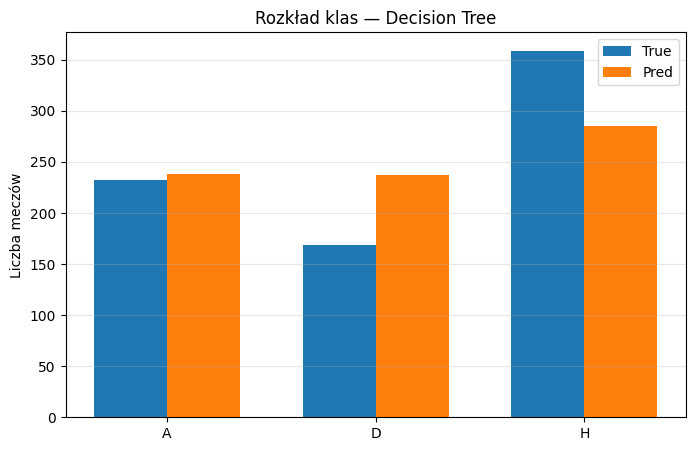

,Class,True_Count,Pred_Count
0,A,232,238
1,D,169,237
2,H,359,285


In [17]:
y_true_cls_dt = le_dt.inverse_transform(y_test_dt)
y_pred_cls_dt = le_dt.inverse_transform(y_pred_dt)

plot_and_save_class_distribution(
    y_true_cls_dt,
    y_pred_cls_dt,
    option_suffix="Decision Tree",
    filename_prefix="class_distribution"
)


,Metric,Baseline_HomeWin,Decision_Tree,Gain_vs_Baseline
0,Accuracy,0.472368,0.518421,0.046053
1,Macro-F1,0.213881,0.495760,0.281879


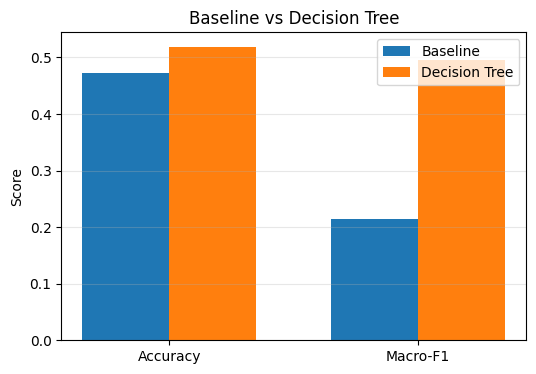

In [18]:

y_true_cls = y_true_cls_dt.tolist()


y_naive = ["H"] * len(y_true_cls)
acc_naive = accuracy_score(y_true_cls, y_naive)
f1_naive  = f1_score(y_true_cls, y_naive, average="macro")

acc_model = accuracy_score(y_true_cls, y_pred_cls_dt)
f1_model  = f1_score(y_true_cls, y_pred_cls_dt, average="macro")

df_baseline_compare = pd.DataFrame({
    "Metric": ["Accuracy", "Macro-F1"],
    "Baseline_HomeWin": [acc_naive, f1_naive],
    "Decision_Tree": [acc_model, f1_model],
    "Gain_vs_Baseline": [
        acc_model - acc_naive,
        f1_model - f1_naive
    ]
})

save_df(df_baseline_compare, "baseline_vs_decision_tree.csv")
display(df_baseline_compare)


plt.figure(figsize=(6,4))
x = np.arange(2)
width = 0.35

plt.bar(x - width/2, [acc_naive, f1_naive], width, label="Baseline")
plt.bar(x + width/2, [acc_model, f1_model], width, label="Decision Tree")

plt.xticks(x, ["Accuracy", "Macro-F1"])
plt.ylabel("Score")
plt.title("Baseline vs Decision Tree")
plt.legend()
plt.grid(axis="y", alpha=0.3)

save_plot("baseline_vs_decision_tree.png")
plt.show()
close_plot()


C:\Users\tdroz\AppData\Local\Temp\ipykernel_328\812493370.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))


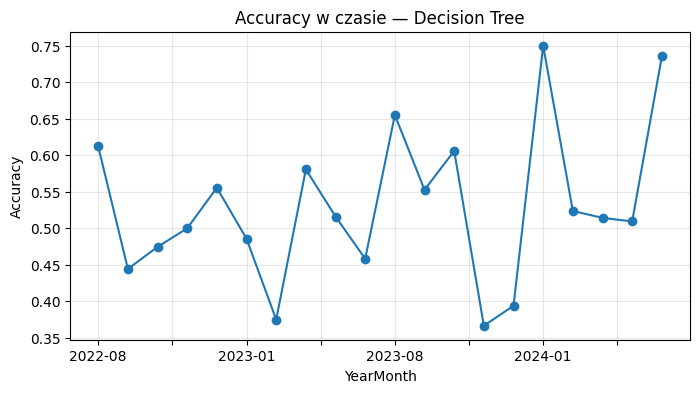

In [19]:
MIN_MATCHES = 10

df_eval_dt = df.loc[test_mask, ["Date"]].copy()
df_eval_dt["y_true"] = y_true_cls_dt
df_eval_dt["y_pred"] = y_pred_cls_dt
df_eval_dt["YearMonth"] = df_eval_dt["Date"].dt.to_period("M").astype(str)

acc_per_month_dt = (
    df_eval_dt
    .groupby("YearMonth")
    .filter(lambda x: len(x) >= MIN_MATCHES)
    .groupby("YearMonth")
    .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))
)
df_acc_decision_tree = (
    acc_per_month_dt
    .reset_index()
    .rename(columns={0: "Accuracy"})
)
df_acc_decision_tree["Model"] = "Decision Tree"

df_acc_decision_tree.to_csv(
    RESULTS_DIR / "accuracy_per_month_decision_tree.csv",
    index=False
)

plt.figure(figsize=(8,4))
acc_per_month_dt.plot(marker="o")
plt.ylabel("Accuracy")
plt.title("Accuracy w czasie — Decision Tree")
plt.grid(alpha=0.3)

save_plot("accuracy_per_month_decision_tree.png")
plt.show()
close_plot()


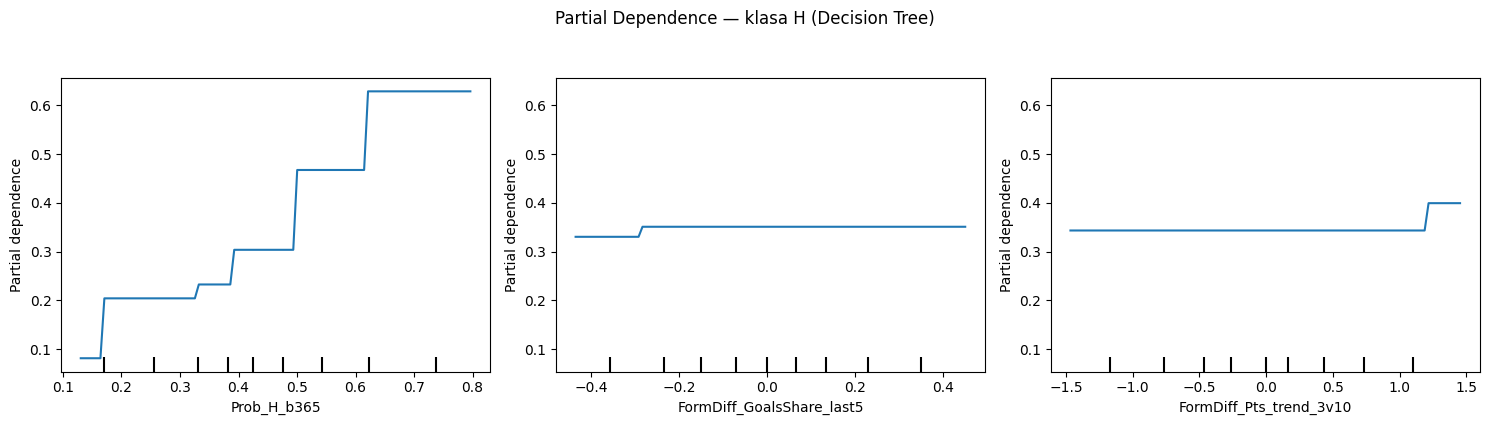

In [20]:
from sklearn.inspection import PartialDependenceDisplay

top_features = feat_imp["feature"].head(3).tolist()
top_features

fig, ax = plt.subplots(1, len(top_features), figsize=(5*len(top_features), 4))

PartialDependenceDisplay.from_estimator(
    best_dt,
    X_train_dt,
    features=top_features,
    target=le_dt.transform(["H"])[0],  # klasa Home Win
    ax=ax
)

plt.suptitle("Partial Dependence — klasa H (Decision Tree)", y=1.05)
plt.tight_layout()

save_plot("pdp_top_features_class_H.png")
plt.show()
close_plot()


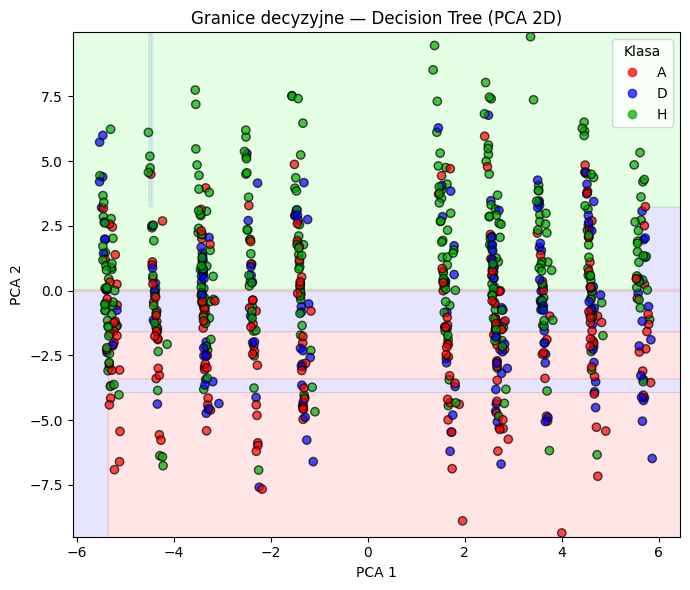

In [21]:
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import ListedColormap


imputer = best_dt.named_steps["imputer"]

X_train_imp = imputer.transform(X_train_dt)
X_test_imp  = imputer.transform(X_test_dt)


pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_imp)
X_test_pca  = pca.transform(X_test_imp)


dt_pca = DecisionTreeClassifier(
    max_depth=best_dt.named_steps["model"].max_depth,
    min_samples_leaf=best_dt.named_steps["model"].min_samples_leaf,
    min_samples_split=best_dt.named_steps["model"].min_samples_split,
    class_weight="balanced",
    random_state=42
)
dt_pca.fit(X_train_pca, y_train_dt)


x_min, x_max = X_train_pca[:, 0].min() - 0.5, X_train_pca[:, 0].max() + 0.5
y_min, y_max = X_train_pca[:, 1].min() - 0.5, X_train_pca[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = dt_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_light = ListedColormap(["#FFAAAA", "#AAAAFF", "#AAFFAA"])
cmap_bold  = ListedColormap(["#FF0000", "#0000FF", "#00AA00"])

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

scatter = plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test_dt,
    cmap=cmap_bold,
    edgecolor="k",
    alpha=0.7
)

handles, labels = scatter.legend_elements()
plt.legend(
    handles,
    le_dt.classes_,
    title="Klasa",
    loc="best"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Granice decyzyjne — Decision Tree (PCA 2D)")
plt.tight_layout()

save_plot("dt_decision_surface_pca_2d.png")
plt.show()
close_plot()

Wizualizacja granic decyzyjnych w przestrzeni PCA 2D pokazuje charakterystyczne, osiowo-aligned regiony decyzyjne typowe dla drzew decyzyjnych. Widoczne pasmowe struktury wynikają zarówno z progowej natury modelu, jak i z redukcji wymiarowości, która powoduje utratę części informacji predykcyjnej. Mieszanie się klas w wielu regionach potwierdza złożoność problemu predykcji wyników meczów piłkarskich.

## Decision Tree — analiza wyników i wnioski

Model klasyfikacyjny **Decision Tree** został wykorzystany jako interpretowalna metoda
predykcji wyniku meczu piłkarskiego (H/D/A) na podstawie zmiennych obejmujących
informację rynkową (kursy bukmacherskie), miary formy drużyn, statystyki sezonowe
oraz dane kontekstowe. Model został wytrenowany w wariancie **wieloklasowym**
(multiclass classification).

---

## Wyniki modelu

Ocena jakości predykcji na zbiorze testowym dała następujące rezultaty:

| Metryka        | Wartość |
|----------------|---------|
| **Accuracy**   | 0.5184  |
| **Macro-F1**   | 0.4958  |

Uzyskane wyniki mieszczą się w typowym zakresie skuteczności raportowanym
w literaturze dla klasycznych modeli uczenia maszynowego stosowanych do
predykcji wyników meczów piłkarskich (ok. 48–55%). Model osiąga porównywalną
skuteczność do prostych metod bazowych, jednak nie przewyższa wyraźnie
wcześniej analizowanego podejścia regresyjnego opartego na predykcji GoalDiff.

---

## Macierz pomyłek — interpretacja

Poniższa macierz pomyłek ilustruje rozkład predykcji modelu na zbiorze testowym:

| True \\ Predicted | A   | D   | H   |
|------------------:|----:|----:|----:|
| **A**             | 128 | 70  | 34  |
| **D**             | 56  | 64  | 49  |
| **H**             | 54  | 103 | 202 |

Analiza macierzy pomyłek prowadzi do następujących wniosków:

- Model **najlepiej rozpoznaje zwycięstwa gospodarzy (H)**, co potwierdza
  najwyższa liczba poprawnych klasyfikacji (202) oraz wysoka precyzja tej klasy.
- Wyniki dla **zwycięstw gości (A)** są umiarkowanie dobre, z relatywnie
  zrównoważoną precyzją i czułością.
- **Remisy (D)** pozostają najtrudniejszą klasą do przewidzenia, zarówno pod
  względem precyzji, jak i recall, co jest powszechnie obserwowanym problemem
  w zadaniach predykcji wyników typu 1X2.

Najczęstsze błędy dotyczą predykcji pomiędzy klasami sąsiadującymi
(A ↔ D oraz D ↔ H). Błędy skrajne (A → H oraz H → A) występują rzadziej,
co wskazuje, że model w większości przypadków poprawnie rozpoznaje
ogólny kierunek wyniku spotkania.

---

## Raport klasyfikacji — uzupełnienie

Szczegółowy raport klasyfikacji potwierdza obserwacje wynikające z macierzy
pomyłek:

- Klasa **H** charakteryzuje się najwyższą precyzją (0.71) oraz umiarkowanym
  recall (0.56), co wskazuje na dobrą identyfikację faworytów gospodarzy.
- Klasa **A** osiąga zrównoważone wartości precision i recall (ok. 0.54–0.55).
- Klasa **D** cechuje się wyraźnie niższą precyzją (0.27), co oznacza dużą liczbę
  fałszywie przewidzianych remisów.

Wartość **Macro-F1 = 0.4958** wskazuje na umiarkowaną, lecz stabilną jakość
predykcji we wszystkich klasach, bez nadmiernego uprzywilejowania klasy
dominującej.

---

## Najważniejsze cechy modelu

Analiza ważności cech pokazuje, że decyzje modelu opierają się głównie na:

1. **Prob_H_b365** — rynkowe prawdopodobieństwo zwycięstwa gospodarzy,
2. **FormDiff_GoalShare_last5** — różnica formy bramkowej z ostatnich meczów,
3. **FormDiff_Pts_trend_3v10** — trend punktowy drużyn,
4. **Home_GA_last5** — liczba straconych bramek gospodarzy,
5. **Home_avgPts_season** — średnia liczba punktów gospodarzy w sezonie.

Struktura ta potwierdza silne znaczenie informacji rynkowej oraz zmiennych
opisujących bieżącą i sezonową formę drużyn.

---

## Krzywa uczenia — charakterystyka modelu

Analiza krzywej uczenia wskazuje, że wraz ze wzrostem liczby próbek treningowych
wartość F1-score na zbiorze treningowym stopniowo maleje (z ok. 0.57 do 0.51),
podczas gdy wynik walidacyjny systematycznie rośnie (z ok. 0.39 do 0.48).

Sugeruje to, że:

- model charakteryzuje się **niskim biasem**,
- jednocześnie wykazuje **wysoki variance**,
- dalsze zwiększanie liczby danych nie prowadzi do istotnej poprawy jakości,
- problem predykcji wyników meczów piłkarskich cechuje się dużym poziomem szumu.

Drzewa decyzyjne są szczególnie podatne na tego typu ograniczenia.

---

## Wnioski końcowe — Decision Tree

Model Decision Tree:

- osiąga **umiarkowaną skuteczność (Accuracy ≈ 0.52)**,
- poprawnie odzwierciedla strukturę trudności problemu H/D/A,
- najlepiej przewiduje zwycięstwa gospodarzy,
- najsłabiej radzi sobie z remisami,
- cechuje się wysoką wariancją i wrażliwością na szum danych,
- silnie polega na zmiennych rynkowych, co jest zgodne z wynikami badań
  empirycznych.

### Podsumowanie

Drzewo decyzyjne stanowi poprawny i interpretowalny punkt odniesienia,
jednak jego ograniczenia są w dużej mierze strukturalne. Istotna poprawa
jakości predykcji wymaga zastosowania metod zespołowych (ensemble),
takich jak Random Forest czy Gradient Boosting.


# Model Random Forest

###  Idea metody Random Forest

Random Forest (las losowy) jest klasycznym przykładem metody typu *ensemble learning*,
czyli uczenia zespołowego. Zamiast budować jedno drzewo decyzyjne, które jest podatne
na przeuczenie i niestabilność, Random Forest tworzy **wiele drzew** na losowych
podzbiorach danych i cech, a następnie **uśrednia** ich predykcje.

Dwa kluczowe elementy tej metody to:

1. **Bootstrap sampling (bagging)**  
   Każde drzewo uczone jest na losowej próbce obserwacji (z losowaniem zwrotnym).
   Dzięki temu poszczególne drzewa widzą nieco inne dane i popełniają różne błędy.

2. **Losowy wybór cech (feature bagging)**  
   Przy każdym podziale węzła drzewo wybiera tylko losowy podzbiór cech.
   Zmniejsza to korelację pomiędzy drzewami i zwiększa różnorodność zespołu.

Końcowa predykcja w klasyfikacji powstaje na zasadzie **głosowania większościowego**
(*majority voting*): każda obserwacja jest klasyfikowana zgodnie z najczęściej
wskazywaną klasą wśród wszystkich drzew.

---

###  Zalety Random Forest

W porównaniu z pojedynczym drzewem decyzyjnym, Random Forest:

- ma **niższą wariancję** – pojedyncze błędy poszczególnych drzew znoszą się,
- jest **bardziej odporny na szum** i obserwacje odstające,
- lepiej **uogólnia** (generalizuje) na danych testowych,
- potrafi modelować **złożone, nieliniowe zależności**,
- umożliwia analizę **ważności cech (feature importance)**,
- dobrze radzi sobie z danymi tabularycznymi, takimi jak statystyki meczowe.

Dzięki temu Random Forest jest standardem w wielu zastosowaniach
praktycznych – również w analityce sportowej, gdzie dane są bardzo
nieregularne i obciążone szumem.

---

### Wady Random Forest

Mimo licznych zalet, Random Forest ma także ograniczenia:

- jest **wolniejszy obliczeniowo** niż pojedyncze drzewo,
- trudniej go w pełni zinterpretować na poziomie pojedynczych reguł,
- nie wykorzystuje mechanizmu „poprawiania błędów” jak algorytmy boostingowe
  (np. XGBoost),
- nadal ma trudności z kategoriami o wysokiej losowości (np. remisy w futbolu),
  choć radzi sobie z nimi lepiej niż proste modele.

---

### Zastosowanie w predykcji wyników meczów

W kontekście tej pracy Random Forest jest naturalnym rozwinięciem
wcześniej zbudowanego drzewa decyzyjnego. Dane meczowe:

- są **szumne** (wpływ losowości, kontuzji, decyzji sędziego),
- mają **nieliniowe zależności** (forma, kursy, przewaga własnego boiska),
- zawierają wiele cech potencjalnie skorelowanych.

Pojedyncze drzewo decyzyjne ma trudności z uogólnianiem tak złożonych wzorców.
Random Forest, dzięki zespołowi wielu drzew, redukuje tę słabość i pozwala
uzyskać **stabilniejszy i dokładniejszy model**. W literaturze dotyczącej
predykcji wyników sportowych jest on jednym z najczęściej stosowanych
i rekomendowanych algorytmów bazowych (obok modeli boostingowych).

W kolejnych podrozdziałach przedstawiono budowę modelu Random Forest,
dobór hiperparametrów oraz analizę jego wyników.


In [22]:

# KONFIGURACJA ZAPISU — RANDOM FOREST

MODEL_NAME = "random_forest"

RESULTS_DIR = Path(f"../results/{LEAGUE}/{MODEL_NAME}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [23]:
sns.set_theme(style="whitegrid")


# 1. Przygotowanie danych (H/D/A)


target = "FTR"
le_rf = LabelEncoder()
y_all = le_rf.fit_transform(df[target].values)

# ten sam podział czasowy co wcześniej
split_date = pd.Timestamp("2022-07-01")
train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date

X = df[X_features].copy()

X_train_rf = X.loc[train_mask].reset_index(drop=True)
X_test_rf  = X.loc[test_mask].reset_index(drop=True)
y_train_rf = y_all[train_mask]
y_test_rf  = y_all[test_mask]

print("Train:", X_train_rf.shape, " Test:", X_test_rf.shape)
print("Klasy:", le_rf.classes_)

Train: (2660, 32)  Test: (760, 32)
Klasy: ['A' 'D' 'H']


In [24]:
from sklearn.ensemble import RandomForestClassifier
# 2. Pipeline + model bazowy
def make_rf_pipeline(model):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model)
    ])

rf_base = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=0,
    n_jobs=-1
)
pipe_rf_base = make_rf_pipeline(rf_base)
pipe_rf_base.fit(X_train_rf, y_train_rf)

y_pred_base = pipe_rf_base.predict(X_test_rf)
print("\n=== Random Forest (model bazowy) ===")
print("Accuracy:", accuracy_score(y_test_rf, y_pred_base))
print("Macro-F1:", f1_score(y_test_rf, y_pred_base, average="macro"))


=== Random Forest (model bazowy) ===
Accuracy: 0.5592105263157895
Macro-F1: 0.4378416202188528


In [25]:

'''

rf = RandomForestClassifier(random_state=0)
pipe_rf = make_rf_pipeline(rf)

param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [1,3,5, 10],
    "model__min_samples_leaf": [1, 5, 20],
    "model__max_features": ["sqrt", "log2", 0.6, 0.8]
}
grid_rf = GridSearchCV(
    pipe_rf,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

print("\nTrenowanie GridSearchCV (RandomForest)...")
grid_rf.fit(X_train_rf, y_train_rf)

print("Najlepsze parametry:", grid_rf.best_params_)
print("Najlepszy wynik CV (Macro-F1):", grid_rf.best_score_)
best_rf = grid_rf.best_estimator_

'''



rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=8,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features=0.3,
    max_samples =0.8,
    class_weight="balanced",
    random_state=0,
    n_jobs=-1
)

best_rf = make_rf_pipeline(rf)
best_rf.fit(X_train_rf, y_train_rf)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        max_features=0.3, max_samples=0.8,
                                        min_samples_leaf=10,
                                        min_samples_split=20, n_estimators=600,
                                        n_jobs=-1, random_state=0))])


=== Random Forest (multiclass H/D/A) — TEST ===
Accuracy: 0.5355
Macro-F1: 0.4885

=== Classification report (Random Forest) ===
              precision    recall  f1-score   support

           A       0.52      0.60      0.56       232
           D       0.28      0.25      0.26       169
           H       0.66      0.63      0.64       359

    accuracy                           0.54       760
   macro avg       0.49      0.49      0.49       760
weighted avg       0.53      0.54      0.53       760



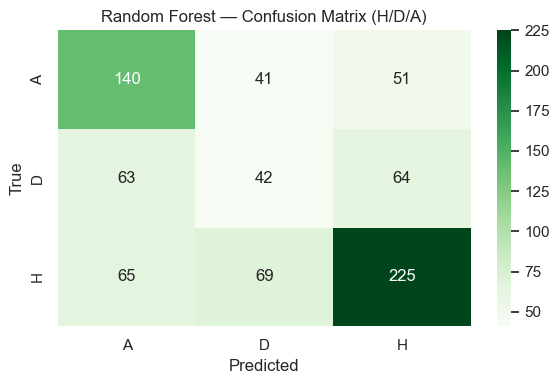

In [26]:

# 4. Ewaluacja na zbiorze testowym

proba = best_rf.predict_proba(X_test_rf)
classes = le_rf.classes_          
idx_D = list(classes).index("D") 

y_pred_rf = []

for p in proba:
    order = np.argsort(p)[::-1]
    top = order[0]

    if top == idx_D and p[top] < 0.35:
        y_pred_rf.append(order[1])   
    else:
        y_pred_rf.append(top)        

acc_rf = accuracy_score(y_test_rf, y_pred_rf)
f1m_rf = f1_score(y_test_rf, y_pred_rf, average="macro")

print("\n=== Random Forest (multiclass H/D/A) — TEST ===")
print("Accuracy:", f"{acc_rf:.4f}")
print("Macro-F1:", f"{f1m_rf:.4f}")
print("\n=== Classification report (Random Forest) ===")
print(classification_report(y_test_rf, y_pred_rf, target_names=le_rf.classes_))

# 5. Macierz pomyłek


cm_rf = confusion_matrix(y_test_rf, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=le_rf.classes_,
    yticklabels=le_rf.classes_
)
plt.title("Random Forest — Confusion Matrix (H/D/A)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
save_plot("random_forest_confusion_matrix.png")
plt.show()
close_plot()


In [27]:
results_rf = pd.DataFrame([{
    "Model": "Random Forest",
    "Accuracy": acc_rf,
    "Macro-F1": f1m_rf,
    "League": LEAGUE,
    "SplitDate": split_date,
    "N_train": len(y_train_rf),
    "N_test": len(y_test_rf)
}])

save_df(results_rf, "random_forest_results.csv")


In [28]:
report_rf = classification_report(
    y_test_rf,
    y_pred_rf,
    target_names=le_rf.classes_,
    output_dict=True
)

df_report_rf = pd.DataFrame(report_rf).T
df_report_rf["Model"] = "Random Forest"
df_report_rf["League"] = LEAGUE

save_df(df_report_rf, "random_forest_classification_report.csv")


C:\Users\tdroz\AppData\Local\Temp\ipykernel_328\3961232150.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


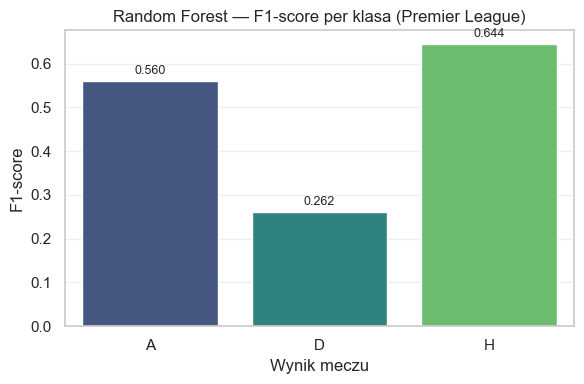

In [29]:
df_f1_class_rf = (
    df_report_rf
    .loc[le_rf.classes_, ["f1-score"]]
    .reset_index()
    .rename(columns={"index": "Outcome"})
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_f1_class_rf,
    x="Outcome",
    y="f1-score",
    palette="viridis"
)


for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title(f"Random Forest — F1-score per klasa ({current_league_name})")
plt.xlabel("Wynik meczu")
plt.ylabel("F1-score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


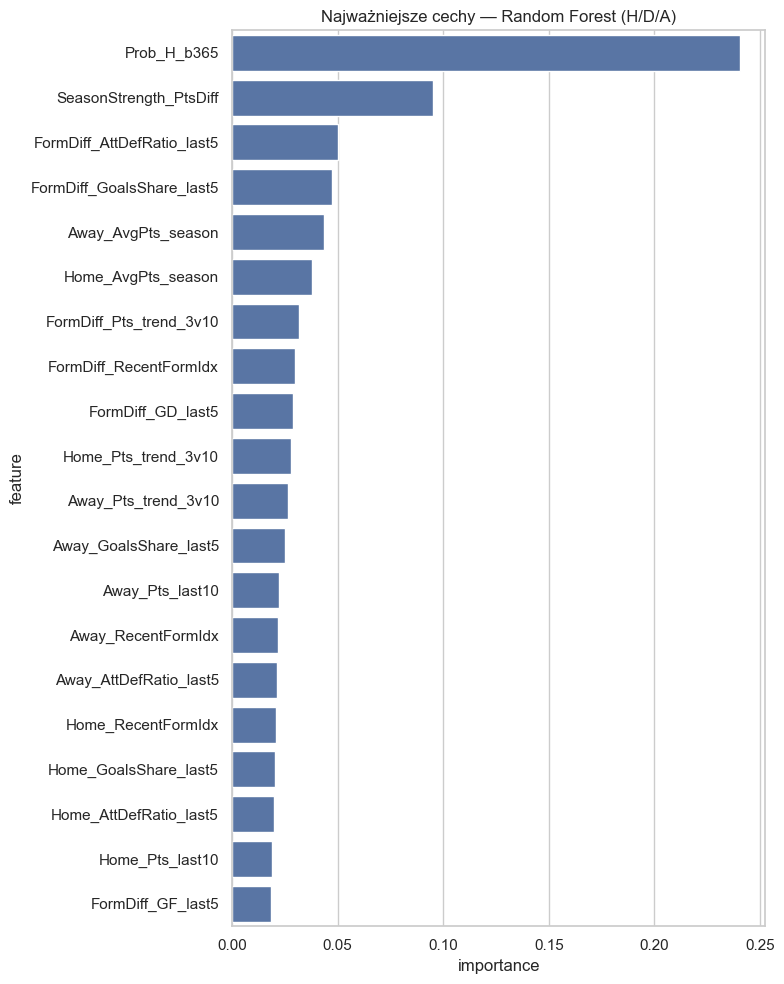

In [30]:
rf_model = best_rf.named_steps["model"]
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({
    "feature": X_train_rf.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

top_n = 20
top_imp = feat_imp.head(top_n)

plt.figure(figsize=(8, 0.4*top_n + 2))
sns.barplot(
    data=top_imp,
    x="importance",
    y="feature"
)
plt.title("Najważniejsze cechy — Random Forest (H/D/A)")
plt.xlabel("importance")
plt.ylabel("feature")
plt.tight_layout()
plt.show()

OOB accuracy: 0.512781954887218


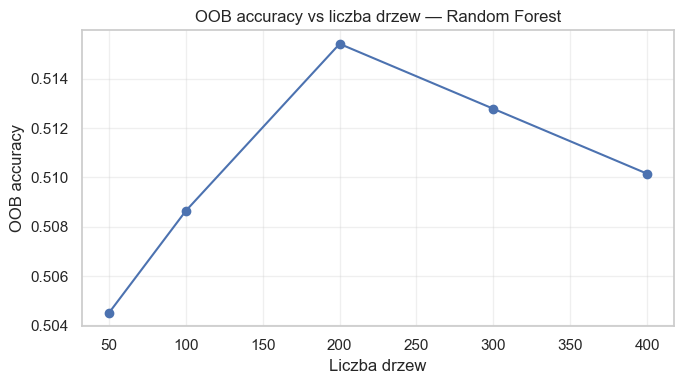

In [31]:

# OOB error — Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = best_rf.named_steps["model"]

rf_oob = RandomForestClassifier(
    n_estimators=300,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_depth=rf_model.max_depth,
    min_samples_split=rf_model.min_samples_split,
    min_samples_leaf=rf_model.min_samples_leaf,
    max_features=rf_model.max_features
)

rf_oob_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", rf_oob)
])

rf_oob_pipe.fit(X_train_rf, y_train_rf)
print("OOB accuracy:", rf_oob.oob_score_)

# OOB vs liczba drzew
oob_scores = []
n_list = [50, 100, 200, 300, 400]

for n in n_list:
    rf_tmp = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        max_depth=rf_model.max_depth,
        min_samples_split=rf_model.min_samples_split,
        min_samples_leaf=rf_model.min_samples_leaf,
        max_features=rf_model.max_features
    )

    pipe_tmp = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", rf_tmp)
    ])
    pipe_tmp.fit(X_train_rf, y_train_rf)
    oob_scores.append(rf_tmp.oob_score_)

plt.figure(figsize=(7,4))
plt.plot(n_list, oob_scores, "o-")
plt.xlabel("Liczba drzew")
plt.ylabel("OOB accuracy")
plt.title("OOB accuracy vs liczba drzew — Random Forest")
plt.grid(alpha=0.3)
plt.tight_layout()

save_plot("random_forest_oob_curve.png")
plt.show()
close_plot()


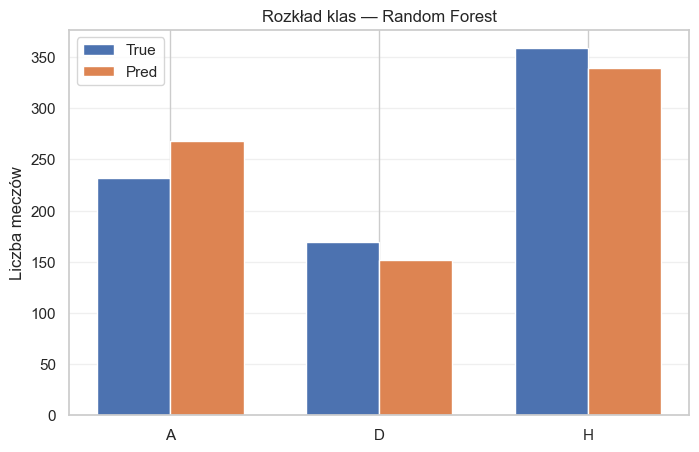

,Class,True_Count,Pred_Count
0,A,232,268
1,D,169,152
2,H,359,340


In [32]:

# Rozkład klas — Random Forest

y_true_cls_rf = le_rf.inverse_transform(y_test_rf)
y_pred_cls_rf = le_rf.inverse_transform(y_pred_rf)

plot_and_save_class_distribution(
    y_true_cls_rf,
    y_pred_cls_rf,
    option_suffix="Random Forest",
    filename_prefix="class_distribution"
)


,Metric,Baseline_HomeWin,Random_Forest,Gain_vs_Baseline
0,Accuracy,0.472368,0.535526,0.063158
1,Macro-F1,0.213881,0.488486,0.274605


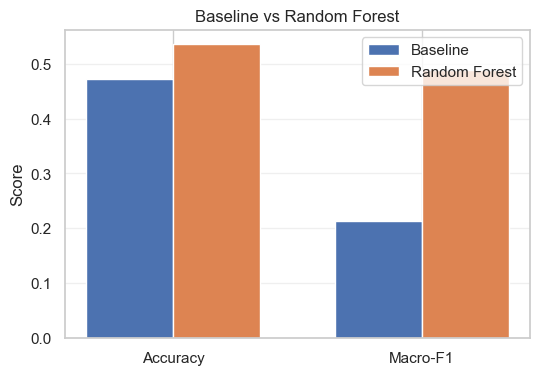

In [33]:

# BASELINE vs RANDOM FOREST

y_true_cls = y_true_cls_rf.tolist()

y_naive = ["H"] * len(y_true_cls)
acc_naive = accuracy_score(y_true_cls, y_naive)
f1_naive  = f1_score(y_true_cls, y_naive, average="macro")

acc_model = accuracy_score(y_true_cls, y_pred_cls_rf)
f1_model  = f1_score(y_true_cls, y_pred_cls_rf, average="macro")

df_baseline_compare = pd.DataFrame({
    "Metric": ["Accuracy", "Macro-F1"],
    "Baseline_HomeWin": [acc_naive, f1_naive],
    "Random_Forest": [acc_model, f1_model],
    "Gain_vs_Baseline": [
        acc_model - acc_naive,
        f1_model - f1_naive
    ]
})

save_df(df_baseline_compare, "baseline_vs_random_forest.csv")
display(df_baseline_compare)


plt.figure(figsize=(6,4))
x = np.arange(2)
width = 0.35

plt.bar(x - width/2, [acc_naive, f1_naive], width, label="Baseline")
plt.bar(x + width/2, [acc_model, f1_model], width, label="Random Forest")

plt.xticks(x, ["Accuracy", "Macro-F1"])
plt.ylabel("Score")
plt.title("Baseline vs Random Forest")
plt.legend()
plt.grid(axis="y", alpha=0.3)

save_plot("baseline_vs_random_forest.png")
plt.show()
close_plot()


C:\Users\tdroz\AppData\Local\Temp\ipykernel_328\106101125.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))


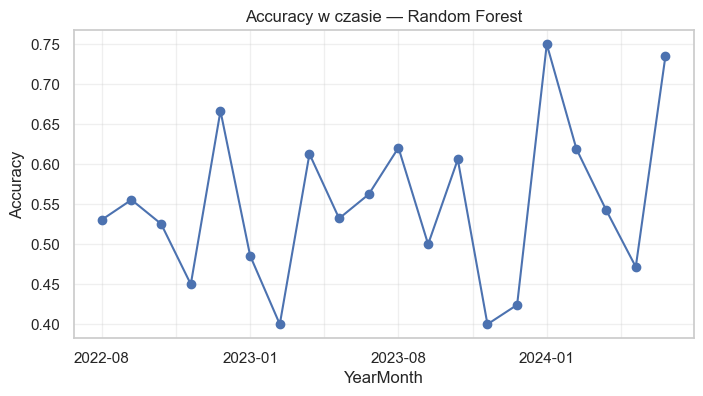

In [34]:

# Accuracy w czasie — Random Forest

MIN_MATCHES = 10

df_eval_rf = df.loc[test_mask, ["Date"]].copy()
df_eval_rf["y_true"] = y_true_cls_rf
df_eval_rf["y_pred"] = y_pred_cls_rf
df_eval_rf["YearMonth"] = df_eval_rf["Date"].dt.to_period("M").astype(str)

acc_per_month_rf = (
    df_eval_rf
    .groupby("YearMonth")
    .filter(lambda x: len(x) >= MIN_MATCHES)
    .groupby("YearMonth")
    .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))
)
df_acc_random_forest = (
    acc_per_month_rf
    .reset_index()
    .rename(columns={0: "Accuracy"})
)
df_acc_random_forest["Model"] = "Random Forest"

df_acc_random_forest.to_csv(
    RESULTS_DIR / "accuracy_per_month_random_forest.csv",
    index=False
)

plt.figure(figsize=(8,4))
acc_per_month_rf.plot(marker="o")
plt.ylabel("Accuracy")
plt.title("Accuracy w czasie — Random Forest")
plt.grid(alpha=0.3)

save_plot("accuracy_per_month_random_forest.png")
plt.show()
close_plot()


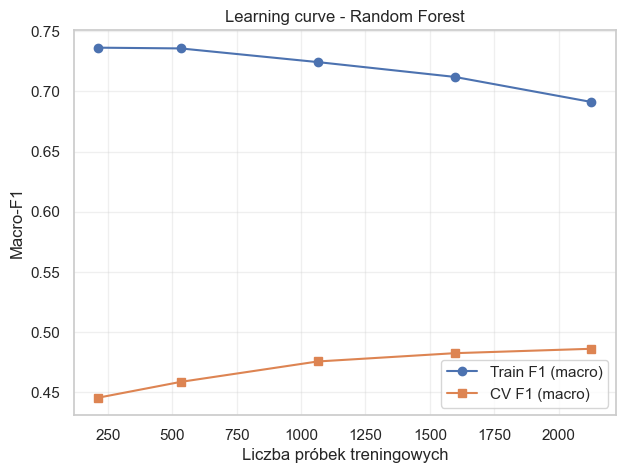

In [35]:

# 7. Learning curve — F1 (macro)
train_sizes, train_scores, val_scores = learning_curve(
    best_rf,
    X_train_rf,
    y_train_rf,
    cv=5,
    scoring="f1_macro",
    train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0],
    shuffle=True,
    random_state=0,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, "o-", label="Train F1 (macro)")
plt.plot(train_sizes, val_mean, "s-", label="CV F1 (macro)")
plt.xlabel("Liczba próbek treningowych")
plt.ylabel("Macro-F1")
plt.title("Learning curve - Random Forest")
plt.legend()
plt.grid(alpha=0.3)
df_learning_rf = pd.DataFrame({
    "TrainSize": train_sizes,
    "Train_F1": train_mean,
    "CV_F1": val_mean
})

save_df(df_learning_rf, "random_forest_learning_curve.csv")
save_plot("random_forest_learning_curve.png")
plt.show()
close_plot()

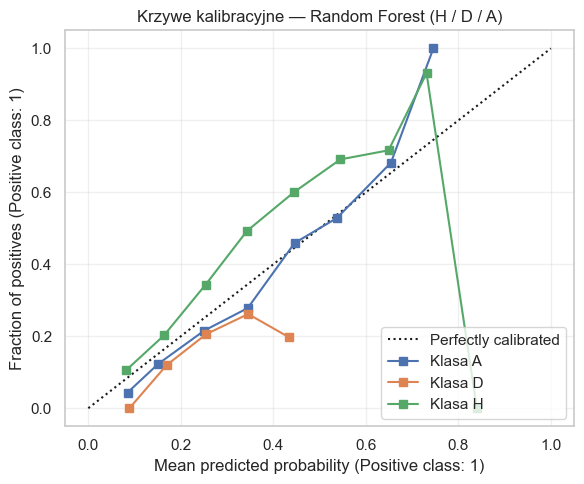

In [36]:
# 8. Krzywa kalibracji — Random Forest (wszystkie klasy na jednym wykresie)

y_proba_rf = best_rf.predict_proba(X_test_rf)

fig, ax = plt.subplots(figsize=(6, 5))   

for i, cls in enumerate(le_rf.classes_):
    CalibrationDisplay.from_predictions(
        (y_test_rf == i).astype(int),
        y_proba_rf[:, i],
        n_bins=10,
        ax=ax,                             
        name=f"Klasa {cls}"
    )

ax.set_title("Krzywe kalibracyjne — Random Forest (H / D / A)")
ax.grid(alpha=0.3)

plt.tight_layout()
save_plot("random_forest_calibration_all_classes.png")
plt.show()
close_plot()


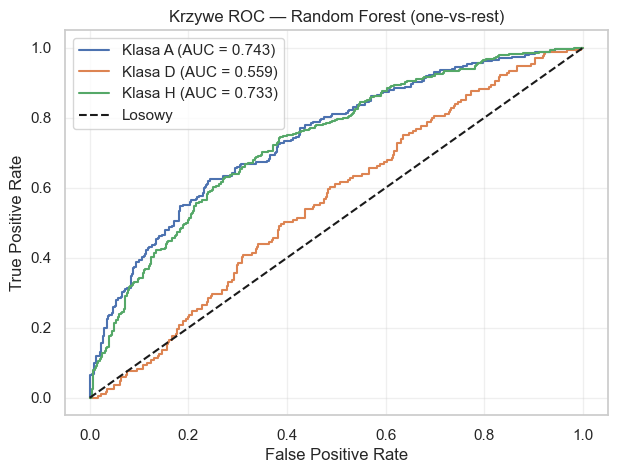

In [37]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


y_test_bin = label_binarize(y_test_rf, classes=np.arange(len(le_rf.classes_)))
y_proba = best_rf.predict_proba(X_test_rf)

plt.figure(figsize=(7,5))
for i, cls in enumerate(le_rf.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Klasa {cls} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="Losowy")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywe ROC — Random Forest (one-vs-rest)")
plt.legend()
plt.grid(alpha=0.3)
save_plot("random_forest_roc_curves.png")
plt.show()
close_plot()

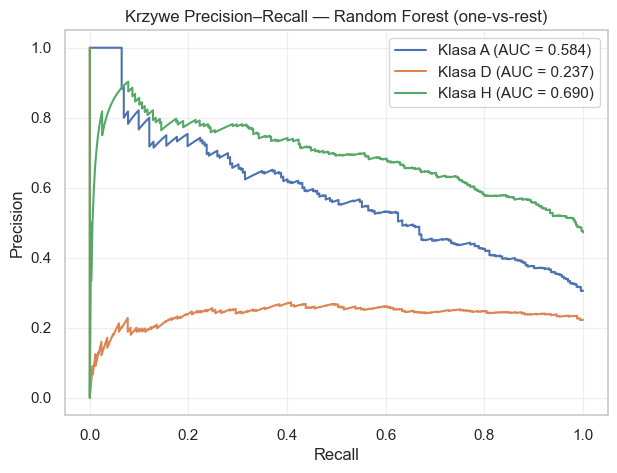

In [38]:
from sklearn.metrics import precision_recall_curve


plt.figure(figsize=(7,5))
for i, cls in enumerate(le_rf.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"Klasa {cls} (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Krzywe Precision–Recall — Random Forest (one-vs-rest)")
plt.legend()
plt.grid(alpha=0.3)
save_plot("random_forest_precision_recall_curves.png")
plt.show()
close_plot()

# Random Forest — podsumowanie i wnioski

Model Random Forest został zastosowany jako zaawansowana metoda typu *ensemble*,
wykorzystująca wiele drzew decyzyjnych do predykcji wyniku meczu piłkarskiego
w klasyfikacji wieloklasowej H/D/A (zwycięstwo gospodarzy / remis / zwycięstwo gości).
Ze względu na odporność na szum oraz zdolność modelowania nieliniowych zależności,
stanowi on naturalne rozszerzenie względem pojedynczego drzewa decyzyjnego.

---

## Wyniki modelu

Model osiągnął następujące wyniki na zbiorze testowym:

| Metryka     | Wartość |
|-------------|---------|
| Accuracy    | 0.5355  |
| Macro-F1    | 0.4885  |

Uzyskana skuteczność jest zgodna z wynikami raportowanymi w literaturze dotyczącej
predykcji wyników meczów piłkarskich, gdzie nawet zaawansowane modele uczenia
maszynowego rzadko przekraczają poziom 55–56% accuracy.

Random Forest wypada lepiej niż Logistic Regression oraz pojedyncze drzewo decyzyjne,
zapewniając jednocześnie większą stabilność predykcji i mniejszą podatność na
przeuczenie.

---

## Interpretacja macierzy pomyłek

Analiza macierzy pomyłek ujawnia typowy dla piłki nożnej wzorzec predykcji:

- **Zwycięstwa gospodarzy (H)** są przewidywane najlepiej  
  (najwyższy recall = 0.63 oraz f1-score = 0.64),
- **Zwycięstwa gości (A)** osiągają umiarkowaną skuteczność  
  (recall = 0.60, f1-score = 0.56),
- **Remisy (D)** pozostają zdecydowanie najtrudniejszą klasą do przewidzenia  
  (recall = 0.25, f1-score = 0.26).

Trudność w predykcji remisów nie stanowi wady modelu, lecz odzwierciedla
rzeczywistą losowość tej kategorii oraz brak jednoznacznych sygnałów
statystycznych w danych meczowych.

---

## Ważność cech i interpretacja

Analiza ważności cech wskazuje, że model opiera swoje decyzje przede wszystkim na:

- **Prob_H_b365** — rynkowym prawdopodobieństwie zwycięstwa gospodarzy,
- **SeasonStrength_PtsDiff** — różnicy siły sezonowej drużyn,
- **FormDiff_AttDefRatio_last5** oraz **FormDiff_GoalsShare_last5** —
  krótkoterminowej formie ofensywno-defensywnej,
- cechach opisujących średnie zdobycze punktowe drużyn w sezonie.

Wyniki te potwierdzają, że Random Forest łączy informacje rynkowe
z danymi opisującymi aktualną formę i długoterminową jakość zespołów,
co zwiększa stabilność predykcji.


---

## Wnioski końcowe

Random Forest jest modelem:

- stabilnym i odpornym na szum,
- wyraźnie skuteczniejszym niż pojedyncze drzewo decyzyjne,
- dobrze zbalansowanym pod względem bias–variance,
- zgodnym z wynikami literatury z zakresu *sports analytics*.

Model najlepiej przewiduje zwycięstwa gospodarzy, najsłabiej radzi sobie
z remisami, a największą wartość predykcyjną niosą informacje rynkowe
oraz cechy opisujące bieżącą formę drużyn.

Stanowi on solidną bazę odniesienia dla dalszych, bardziej zaawansowanych
metod zespołowych, takich jak XGBoost, LightGBM czy CatBoost.


# XGBoost


##  XGBoost – model gradientowego wzmacniania drzew

XGBoost (*Extreme Gradient Boosting*) jest jedną z najpopularniejszych metod uczenia maszynowego
stosowanych w praktycznych zadaniach klasyfikacji i regresji.  
Jest to model z rodziny **gradient boosting**, który buduje kolejne drzewa decyzyjne w sposób sekwencyjny,
tak aby każde następne drzewo poprawiało błędy popełniane przez poprzednie.

W odróżnieniu od pojedynczego drzewa decyzyjnego czy klasycznego Random Forest:

- **Decision Tree** – buduje jedno drzewo, które łatwo się przeucza i jest niestabilne,  
- **Random Forest** – buduje wiele drzew równolegle (bagging), redukując wariancję,  
- **XGBoost** – buduje drzewa sekwencyjnie (boosting), minimalizując błąd za pomocą gradientu funkcji straty.

###  Idea gradient boosting

Algorytm boostingowy działa iteracyjnie:

1. Startuje od prostego modelu bazowego (np. stała wartość).
2. Liczy **reszty/błędy** (różnice między prawdziwą wartością a predykcją).
3. Uczy kolejne drzewo tak, aby jak najlepiej przybliżyć te błędy (gradient funkcji straty).
4. Aktualizuje model jako sumę dotychczasowych drzew + nowe drzewo (z odpowiednim współczynnikiem uczenia).
5. Powtarza kroki 2–4 aż do osiągnięcia założonej liczby drzew lub spełnienia kryterium stopu.

W przypadku klasyfikacji wieloklasowej (H/D/A) XGBoost uczy w tle kilka „logitów” (po jednym na klasę),
a następnie przekształca je do prawdopodobieństw za pomocą funkcji softmax.

### Najważniejsze hiperparametry XGBoost

Kilka kluczowych parametrów steruje złożonością i zachowaniem modelu:

- `n_estimators` – liczba drzew w ensamblu (większa wartość = większa złożoność, potencjalnie lepsze dopasowanie, ale większe ryzyko przeuczenia),
- `max_depth` – maksymalna głębokość pojedynczego drzewa,
- `learning_rate` (alias `eta`) – współczynnik uczenia; mniejsze wartości stabilizują uczenie, ale wymagają większej liczby drzew,
- `subsample` – ułamek próbek używanych do uczenia każdego drzewa (kontroluje wariancję i odporność na szum),
- `colsample_bytree` – ułamek cech używanych przy budowie każdego drzewa (działa podobnie do losowego wyboru cech w Random Forest),
- `min_child_weight` – minimalna „waga” (łączna suma wag) w liściu; większe wartości ograniczają przeuczenie,
- `gamma` – minimalna poprawa funkcji celu wymagana do podziału węzła; działa jak regularyzacja struktury drzewa,
- `reg_lambda`, `reg_alpha` – regularyzacja L2 i L1 na poziomie wag modelu.

Dla klasyfikacji wieloklasowej stosujemy m.in.:

- `objective="multi:softprob"` – model zwraca prawdopodobieństwa dla każdej klasy,
- `num_class=3` – liczba klas (H, D, A),
- `eval_metric="mlogloss"` – log-loss dla wieloklasowej klasyfikacji.

###  Zastosowanie XGBoost w predykcji wyników meczów

W zastosowaniu do predykcji meczów piłkarskich XGBoost ma kilka istotnych zalet:

- potrafi modelować **nieliniowe zależności** między cechami (kursy, forma, siła sezonowa, kalendarz),
- dobrze radzi sobie z **interakcjami cech** (np. formą vs kursy),
- jest bardziej odporny na przeuczenie niż pojedyncze drzewo,
- XGBoost często osiąga lepsze wyniki niż Logistic Regression i pojedyncze
drzewo decyzyjne, a w wielu przypadkach dorównuje lub przewyższa Random Forest,
szczególnie w zadaniach o wysokiej złożoności i nieliniowych zależnościach.


W tej części pracy XGBoost zostanie:

- zastosowany do klasyfikacji wieloklasowej **H/D/A**,  
- wytrenowany na tych samych cechach (`X_features`) co poprzednie modele,  
- oceniony przy użyciu metryk **Accuracy** oraz **Macro-F1**,  
- porównany z wcześniej zbudowanymi modelami (regresja logistyczna, Decision Tree, Random Forest),  
- uzupełniony analizą ważności cech oraz interpretacją predykcji za pomocą biblioteki **SHAP**.


In [39]:
MODEL_NAME = "xgboost"

RESULTS_DIR = Path(f"../results/{LEAGUE}/{MODEL_NAME}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [40]:
target = "FTR"

le_xgb = LabelEncoder()
y_all = le_xgb.fit_transform(df[target].values)

split_date = pd.Timestamp("2022-07-01")
train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date
X = df[X_features].copy()

X_train = X.loc[train_mask].reset_index(drop=True)
X_test  = X.loc[test_mask].reset_index(drop=True)
y_train = y_all[train_mask]
y_test  = y_all[test_mask]

print("Train:", X_train.shape)
print("Test:",  X_test.shape)
print("Klasy:", le_xgb.classes_)

Train: (2660, 32)
Test: (760, 32)
Klasy: ['A' 'D' 'H']


In [41]:
from xgboost import XGBClassifier


imputer_xgb = SimpleImputer(strategy="median")
imputer_xgb.fit(X_train)
X_train_xgb = imputer_xgb.transform(X_train)
X_test_xgb = imputer_xgb.transform(X_test)

xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=0,
    n_jobs=-1
)

xgb_base.fit(X_train_xgb, y_train)
pred_base = xgb_base.predict(X_test_xgb)

print("=== XGBoost (BAZOWY) ===")
print("Accuracy:", accuracy_score(y_test, pred_base))
print("Macro-F1:", f1_score(y_test, pred_base, average="macro"))

=== XGBoost (BAZOWY) ===
Accuracy: 0.5394736842105263
Macro-F1: 0.46509050946092917


In [42]:
# 1
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

def make_xgb_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model)
    ])

results = []

for max_depth in [4, 5, 6]:
    for lr in [0.03, 0.05, 0.1]:
        for n_estimators in [300, 600]:
            for gamma in [0.0, 0.1]:

                model = XGBClassifier(
                    objective="multi:softprob",
                    eval_metric="mlogloss",
                    max_depth=max_depth,
                    learning_rate=lr,
                    n_estimators=n_estimators,
                    subsample=1.0,
                    colsample_bytree=1.0,
                    min_child_weight=2,
                    gamma=gamma,
                    tree_method="hist",
                    random_state=0,
                    n_jobs=-1
                )

                pipe = make_xgb_pipeline(model)

                weights = np.where(
                    y_train == le_xgb.transform(["D"])[0], 1.5, 1.0
                )

                pipe.fit(X_train, y_train, model__sample_weight=weights)

                y_pred = pipe.predict(X_test)

                acc = accuracy_score(y_test, y_pred)
                f1m = f1_score(y_test, y_pred, average="macro")

                results.append({
                    "max_depth": max_depth,
                    "lr": lr,
                    "n_estimators": n_estimators,
                    "gamma": gamma,
                    "accuracy": acc,
                    "macro_f1": f1m
                })

results_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"], ascending=False
)

results_df.head(10)


,max_depth,lr,n_estimators,gamma,accuracy,macro_f1
17,5,0.05,300,0.1,0.536842,0.482501
15,5,0.03,600,0.1,0.531579,0.480398
9,4,0.10,300,0.1,0.528947,0.479822
33,6,0.10,300,0.1,0.539474,0.479755
35,6,0.10,600,0.1,0.539474,0.479755
11,4,0.10,600,0.1,0.528947,0.477942
7,4,0.05,600,0.1,0.528947,0.477414
10,4,0.10,600,0.0,0.527632,0.476845
19,5,0.05,600,0.1,0.531579,0.476196
8,4,0.10,300,0.0,0.527632,0.475868


In [43]:
# 2
xgb_best = XGBClassifier(
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    gamma=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    min_child_weight=2,
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=0,
    n_jobs=-1
)

pipe_xgb = make_xgb_pipeline(xgb_best)


classes = list(le_xgb.classes_)
idx_D = classes.index("D")
idx_A = classes.index("A")


sample_weights = np.where(
    y_train == idx_D, 1.5,
    np.where(y_train == idx_A, 1.15, 1.0)
)

pipe_xgb.fit(
    X_train,
    y_train,
    model__sample_weight=sample_weights
)


xgb_final = pipe_xgb.named_steps["model"]
best_xgb  = pipe_xgb


y_pred = pipe_xgb.predict(X_test)


acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")

print("=== XGBOOST FINAL  ===")
print("Accuracy:", round(acc, 4))
print("Macro-F1:", round(f1m, 4))
print(classification_report(y_test, y_pred, target_names=le_xgb.classes_))


acc_xgb_final = acc
f1m_xgb_final = f1m


=== XGBOOST FINAL  ===
Accuracy: 0.5421
Macro-F1: 0.4831
              precision    recall  f1-score   support

           A       0.54      0.53      0.54       232
           D       0.29      0.22      0.26       169
           H       0.62      0.70      0.66       359

    accuracy                           0.54       760
   macro avg       0.49      0.49      0.48       760
weighted avg       0.52      0.54      0.53       760



In [44]:
'''

from sklearn.utils.class_weight import compute_sample_weight


xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=0
)
pipe_xgb = make_xgb_pipeline(xgb_model)
param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [5, 6, 7],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 2],
    "model__gamma": [0.0, 0.1]
}
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)
weights = compute_sample_weight(class_weight="balanced", y=y_train)

print("Trenuję RandomizedSearchCV...")
grid_xgb.fit(X_train, y_train, model__sample_weight=weights)

print("Najlepsze parametry:")
print(grid_xgb.best_params_)
print("Najlepszy CV Macro-F1:", grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_



y_pred = best_xgb.predict(X_test_xgb)

acc_xgb = accuracy_score(y_test, y_pred)
f1m_xgb = f1_score(y_test, y_pred, average="macro")

print("=== XGBoost (TEST) ===")
print("Accuracy:", acc_xgb)
print("Macro-F1:", f1m_xgb)
print(classification_report(y_test, y_pred, target_names=le_xgb.classes_))

acc_xgb_final = acc_xgb
f1m_xgb_final = f1m_xgb
'''

'\n\nfrom sklearn.utils.class_weight import compute_sample_weight\n\n\nxgb_model = XGBClassifier(\n    objective="multi:softprob",\n    eval_metric="mlogloss",\n    random_state=0\n)\npipe_xgb = make_xgb_pipeline(xgb_model)\nparam_grid = {\n    "model__n_estimators": [300, 500],\n    "model__max_depth": [5, 6, 7],\n    "model__learning_rate": [0.05, 0.1],\n    "model__subsample": [0.8, 1.0],\n    "model__colsample_bytree": [0.8, 1.0],\n    "model__min_child_weight": [1, 2],\n    "model__gamma": [0.0, 0.1]\n}\ngrid_xgb = GridSearchCV(\n    estimator=pipe_xgb,\n    param_grid=param_grid,\n    cv=5,\n    scoring="f1_macro",\n    n_jobs=-1,\n    verbose=2\n)\nweights = compute_sample_weight(class_weight="balanced", y=y_train)\n\nprint("Trenuję RandomizedSearchCV...")\ngrid_xgb.fit(X_train, y_train, model__sample_weight=weights)\n\nprint("Najlepsze parametry:")\nprint(grid_xgb.best_params_)\nprint("Najlepszy CV Macro-F1:", grid_xgb.best_score_)\n\nbest_xgb = grid_xgb.best_estimator_\n\n\n\n

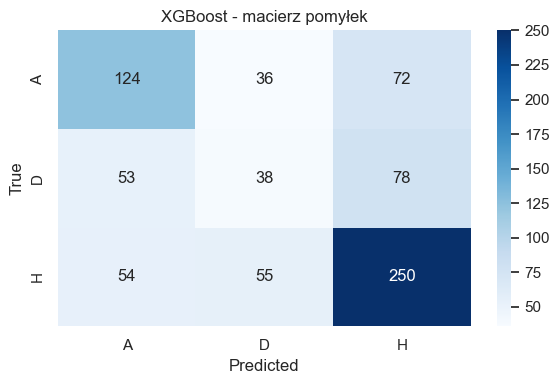

In [45]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_xgb.classes_,
            yticklabels=le_xgb.classes_)
plt.title("XGBoost - macierz pomyłek")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
save_plot("xgboost_confusion_matrix.png")
plt.show()
close_plot()


In [46]:
results_xgb = pd.DataFrame([{
    "Model": "XGBoost",
    "Accuracy": acc_xgb_final,
    "Macro-F1": f1m_xgb_final,
    "League": LEAGUE,
    "SplitDate": split_date,
    "N_train": len(y_train),
    "N_test": len(y_test)
}])

save_df(results_xgb, "xgboost_results.csv")
display(results_xgb)


,Model,Accuracy,Macro-F1,League,SplitDate,N_train,N_test
0,XGBoost,0.542105,0.483144,premier_league,2022-07-01,2660,760


In [47]:

from sklearn.metrics import classification_report
report_xgb = classification_report(
    y_test,
    y_pred,
    target_names=le_xgb.classes_,
    output_dict=True
)


df_report_xgb = pd.DataFrame(report_xgb).T


df_report_xgb["Model"] = "XGBoost"
df_report_xgb["League"] = LEAGUE
df_report_xgb["SplitDate"] = split_date
df_report_xgb["N_train"] = len(y_train)
df_report_xgb["N_test"] = len(y_test)


save_df(df_report_xgb, "xgboost_classification_report.csv")

display(df_report_xgb)


,precision,recall,f1-score,support,Model,League,SplitDate,N_train,N_test
A,0.536797,0.534483,0.535637,232.000000,XGBoost,premier_league,2022-07-01,2660,760
D,0.294574,0.224852,0.255034,169.000000,XGBoost,premier_league,2022-07-01,2660,760
H,0.625000,0.696379,0.658762,359.000000,XGBoost,premier_league,2022-07-01,2660,760
accuracy,0.542105,0.542105,0.542105,0.542105,XGBoost,premier_league,2022-07-01,2660,760
macro avg,0.485457,0.485238,0.483144,760.000000,XGBoost,premier_league,2022-07-01,2660,760
weighted avg,0.524598,0.542105,0.531400,760.000000,XGBoost,premier_league,2022-07-01,2660,760


C:\Users\tdroz\AppData\Local\Temp\ipykernel_328\1462221332.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


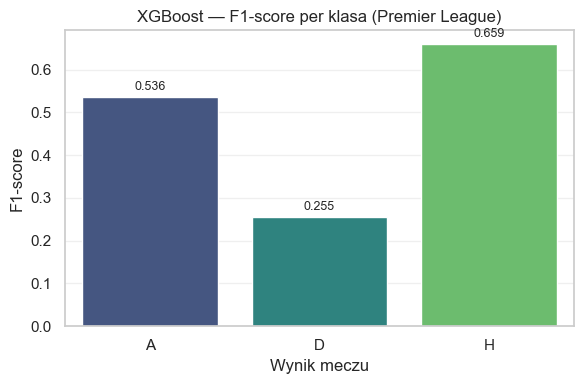

In [48]:
df_f1_class_xgb = (
    df_report_xgb
    .loc[le_xgb.classes_, ["f1-score"]]
    .reset_index()
    .rename(columns={"index": "Outcome"})
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_f1_class_xgb,
    x="Outcome",
    y="f1-score",
    palette="viridis"
)


for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title(f"XGBoost — F1-score per klasa ({current_league_name})")
plt.xlabel("Wynik meczu")
plt.ylabel("F1-score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


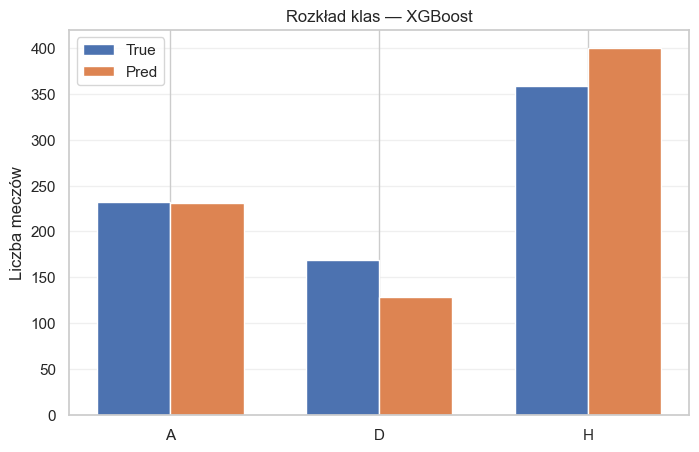

,Class,True_Count,Pred_Count
0,A,232,231
1,D,169,129
2,H,359,400


In [49]:
y_true_cls_xgb = le_xgb.inverse_transform(y_test)
y_pred_cls_xgb = le_xgb.inverse_transform(y_pred)

plot_and_save_class_distribution(
    y_true_cls_xgb,
    y_pred_cls_xgb,
    option_suffix="XGBoost",
    filename_prefix="class_distribution"
)


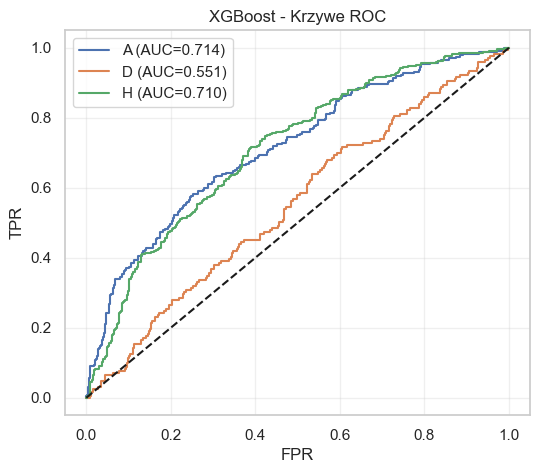

In [50]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
y_test_bin = label_binarize(y_test, classes=np.arange(len(le_xgb.classes_)))
proba = xgb_final.predict_proba(X_test)

plt.figure(figsize=(6,5))

for i, cls in enumerate(le_xgb.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("XGBoost - Krzywe ROC")
plt.legend()
plt.grid(alpha=0.3)
save_plot("xgboost_roc_curves.png")
plt.show()
close_plot()

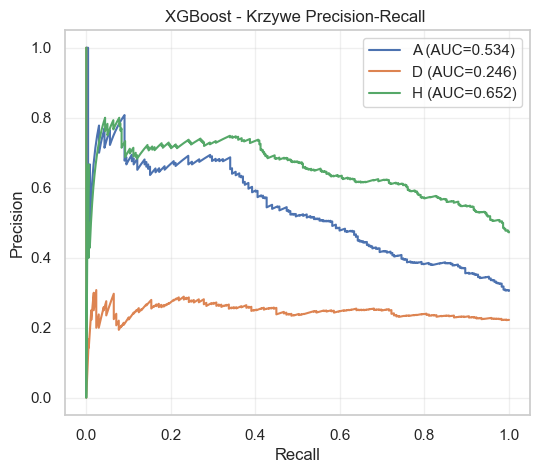

In [51]:
from sklearn.metrics import precision_recall_curve, auc
plt.figure(figsize=(6,5))

for i, cls in enumerate(le_xgb.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], proba[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{cls} (AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost - Krzywe Precision-Recall ")
plt.legend()
plt.grid(alpha=0.3)
save_plot("xgboost_precision_recall.png")
plt.show()
close_plot()

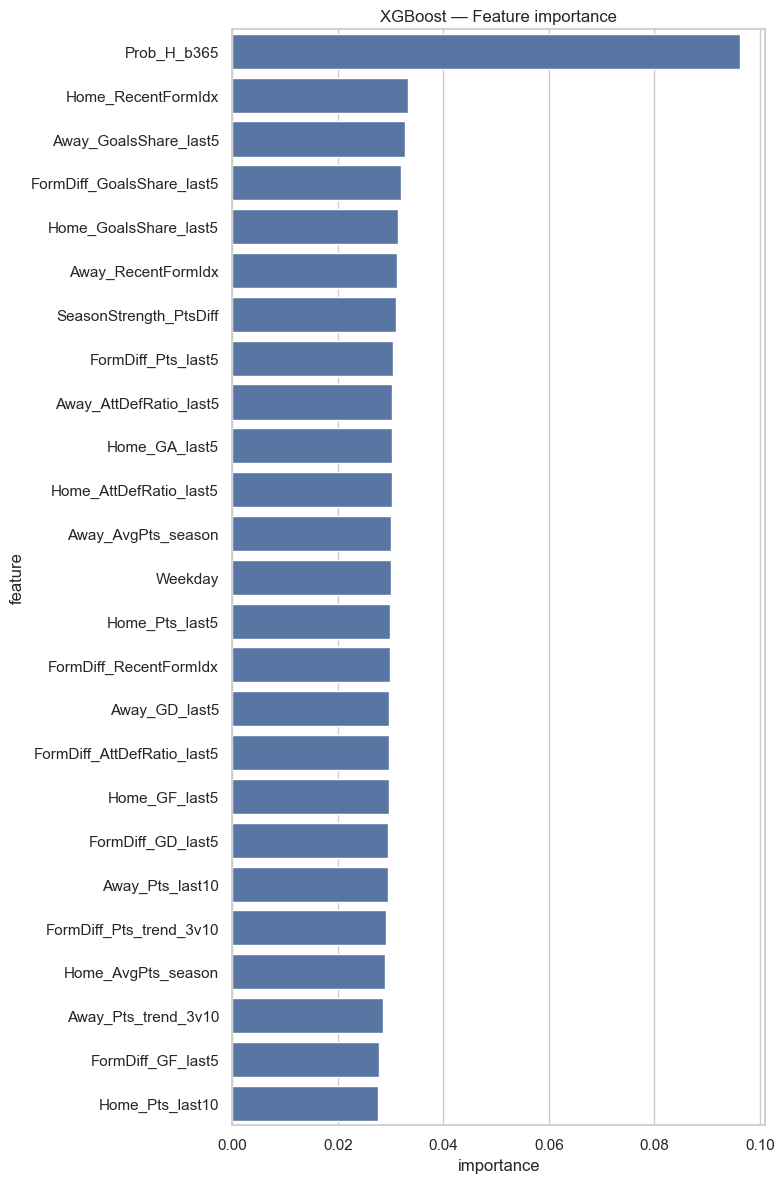

In [52]:
importances = xgb_final.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances,
    "Model": "XGBoost",
    "League": LEAGUE
}).sort_values("importance", ascending=False)

save_df(feat_imp, "xgboost_feature_importance.csv")

plt.figure(figsize=(8,12))
sns.barplot(data=feat_imp.head(25), x="importance", y="feature")
plt.title("XGBoost — Feature importance")
plt.tight_layout()

save_plot("xgboost_feature_importance.png")
plt.show()
close_plot()


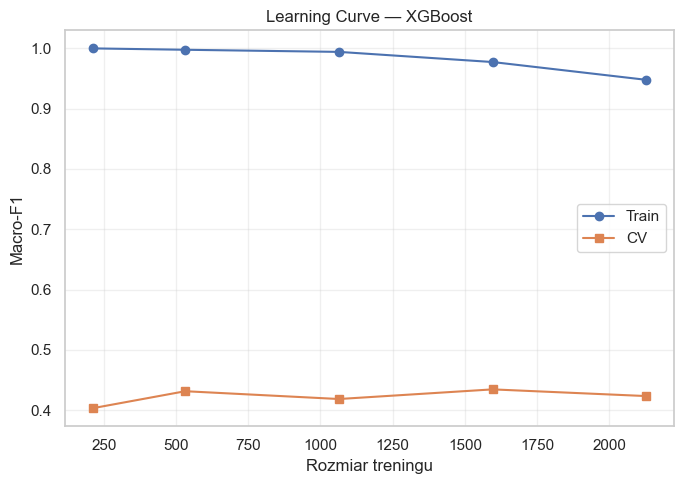

In [53]:
from sklearn.model_selection import learning_curve
train_sizes, tr_scores, val_scores = learning_curve(
    best_xgb, X_train, y_train,
    train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0],
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, tr_scores.mean(axis=1), "o-", label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), "s-", label="CV")
plt.xlabel("Rozmiar treningu")
plt.ylabel("Macro-F1")
plt.title("Learning Curve — XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
save_plot("xgboost_learning_curve.png")
plt.show()
close_plot()


,Metric,Baseline_HomeWin,XGBoost,Gain_vs_Baseline
0,Accuracy,0.472368,0.542105,0.069737
1,Macro-F1,0.213881,0.483144,0.269263


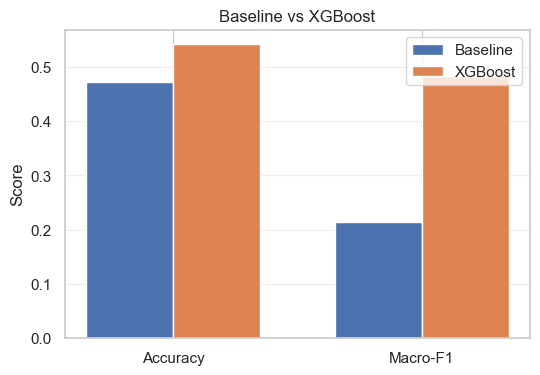

In [54]:
y_true_cls = y_true_cls_xgb.tolist()

y_naive = ["H"] * len(y_true_cls)
acc_naive = accuracy_score(y_true_cls, y_naive)
f1_naive  = f1_score(y_true_cls, y_naive, average="macro")

acc_model = accuracy_score(y_true_cls, y_pred_cls_xgb)
f1_model  = f1_score(y_true_cls, y_pred_cls_xgb, average="macro")

df_baseline_compare = pd.DataFrame({
    "Metric": ["Accuracy", "Macro-F1"],
    "Baseline_HomeWin": [acc_naive, f1_naive],
    "XGBoost": [acc_model, f1_model],
    "Gain_vs_Baseline": [
        acc_model - acc_naive,
        f1_model - f1_naive
    ]
})

save_df(df_baseline_compare, "baseline_vs_xgboost.csv")
display(df_baseline_compare)

plt.figure(figsize=(6,4))
x = np.arange(2)
width = 0.35

plt.bar(x - width/2, [acc_naive, f1_naive], width, label="Baseline")
plt.bar(x + width/2, [acc_model, f1_model], width, label="XGBoost")

plt.xticks(x, ["Accuracy", "Macro-F1"])
plt.ylabel("Score")
plt.title("Baseline vs XGBoost")
plt.legend()
plt.grid(axis="y", alpha=0.3)

save_plot("baseline_vs_xgboost.png")
plt.show()
close_plot()


C:\Users\tdroz\AppData\Local\Temp\ipykernel_328\3809848849.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))


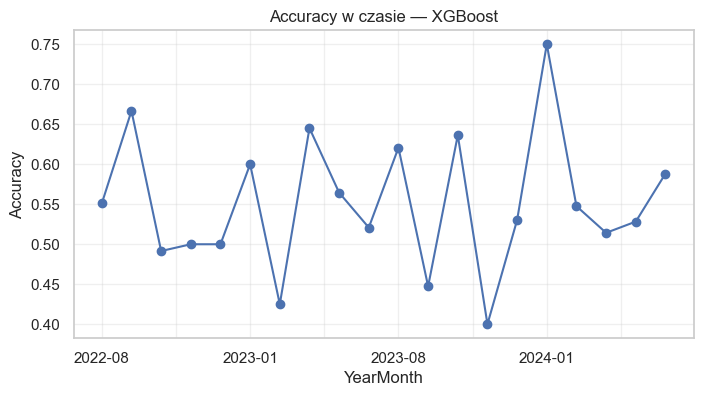

In [55]:
MIN_MATCHES = 10

df_eval_xgb = df.loc[test_mask, ["Date"]].copy()
df_eval_xgb["y_true"] = y_true_cls_xgb
df_eval_xgb["y_pred"] = y_pred_cls_xgb
df_eval_xgb["YearMonth"] = df_eval_xgb["Date"].dt.to_period("M").astype(str)

acc_per_month_xgb = (
    df_eval_xgb
    .groupby("YearMonth")
    .filter(lambda x: len(x) >= MIN_MATCHES)
    .groupby("YearMonth")
    .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))
)
df_acc_xgboost = (
    acc_per_month_xgb
    .reset_index()
    .rename(columns={0: "Accuracy"})
)
df_acc_xgboost["Model"] = "XGBoost"

df_acc_xgboost.to_csv(
    RESULTS_DIR / "accuracy_per_month_xgboost.csv",
    index=False
)

plt.figure(figsize=(8,4))
acc_per_month_xgb.plot(marker="o")
plt.ylabel("Accuracy")
plt.title("Accuracy w czasie — XGBoost")
plt.grid(alpha=0.3)

save_plot("accuracy_per_month_xgboost.png")
plt.show()
close_plot()


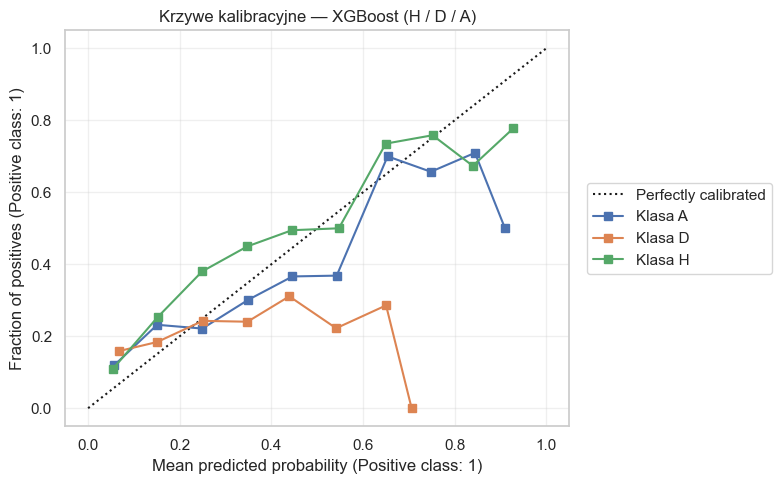

In [56]:
from sklearn.calibration import CalibrationDisplay

y_proba_xgb = xgb_final.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(8, 5))   

for i, cls in enumerate(le_xgb.classes_):
    CalibrationDisplay.from_predictions(
        (y_test == i).astype(int),
        y_proba_xgb[:, i],
        n_bins=10,
        ax=ax,                             
        name=f"Klasa {cls}"
    )

ax.set_title("Krzywe kalibracyjne — XGBoost (H / D / A)")
ax.grid(alpha=0.3)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
save_plot("xgboost_calibration_all_classes.png")
plt.show()
close_plot()


<Figure size 1000x600 with 0 Axes>

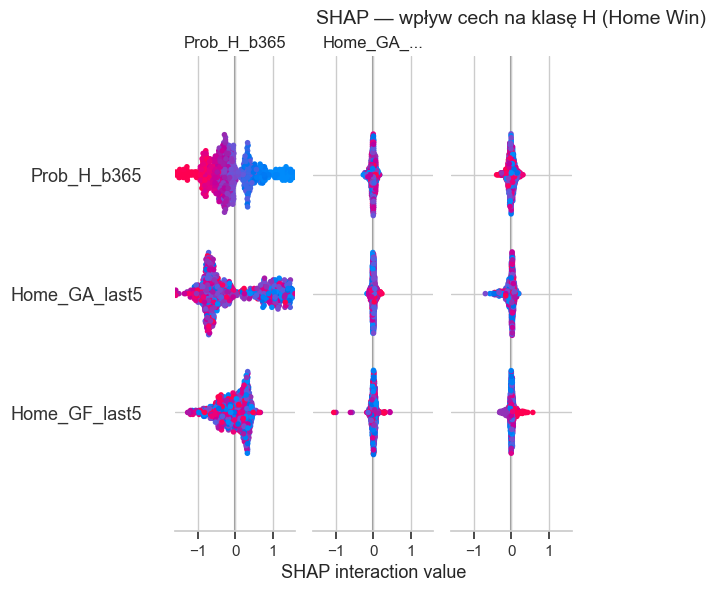

In [57]:
import shap

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)

idx_H = list(le_xgb.classes_).index("H")

plt.figure(figsize=(10, 6))  

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title(
    "SHAP — wpływ cech na klasę H (Home Win)",
    fontsize=14,
    y=1.05                   
)

plt.tight_layout(rect=[0, 0, 1, 0.93])  

save_plot("xgboost_shap_summary_H.png")
plt.show()
close_plot()


shap_values shape: (760, 32, 3)
X_test shape: (760, 32)
Top feature: Prob_H_b365


<Figure size 640x480 with 0 Axes>

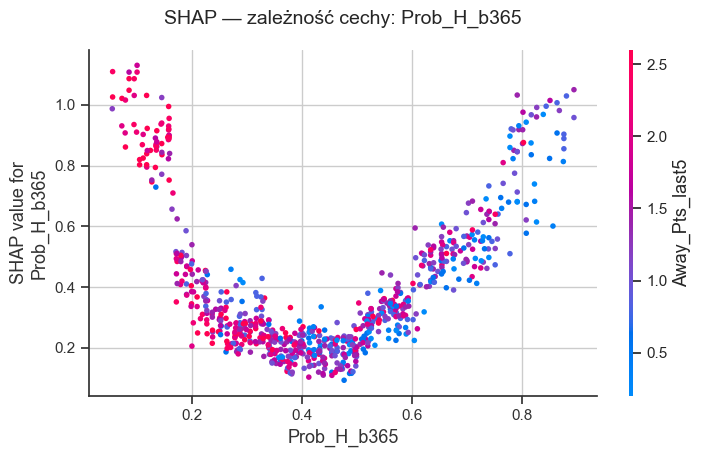

In [58]:
'''
print("shap_values shape:", shap_values.shape)
print("X_test shape:", X_test.shape)

assert shap_values.shape == X_test.shape, "SHAP i X_test muszą mieć ten sam shape"


top_feature = X_test.columns[
    np.abs(shap_values).mean(axis=0).argmax()
]

print("Top feature:", top_feature)


plt.figure()
shap.dependence_plot(
    top_feature,
    shap_values,  
    X_test,
    show=False
)

save_plot(f"xgboost_shap_dependence_{top_feature}.png")
plt.show()
close_plot()
# DLA PREMIER LEAGUE
'''



# SHAP — multiclass dependence plot (FULL CELL)

import numpy as np
import matplotlib.pyplot as plt
import shap


print("shap_values shape:", shap_values.shape)
print("X_test shape:", X_test.shape)


shap_mean = np.abs(shap_values).mean(axis=2)


assert shap_mean.shape == X_test.shape, (
    f"Expected {X_test.shape}, got {shap_mean.shape}"
)


top_feature_idx = shap_mean.mean(axis=0).argmax()
top_feature = X_test.columns[top_feature_idx]

print("Top feature:", top_feature)


plt.figure()
shap.dependence_plot(
    top_feature,
    shap_mean,
    X_test,
    show=False
)
plt.title(
    f"SHAP — zależność cechy: {top_feature}",
    fontsize=14,
    y=1.05                    
)

plt.tight_layout(rect=[0, 0, 1, 0.95])  
save_plot(f"xgboost_shap_dependence_{top_feature}.png")
plt.show()
close_plot()


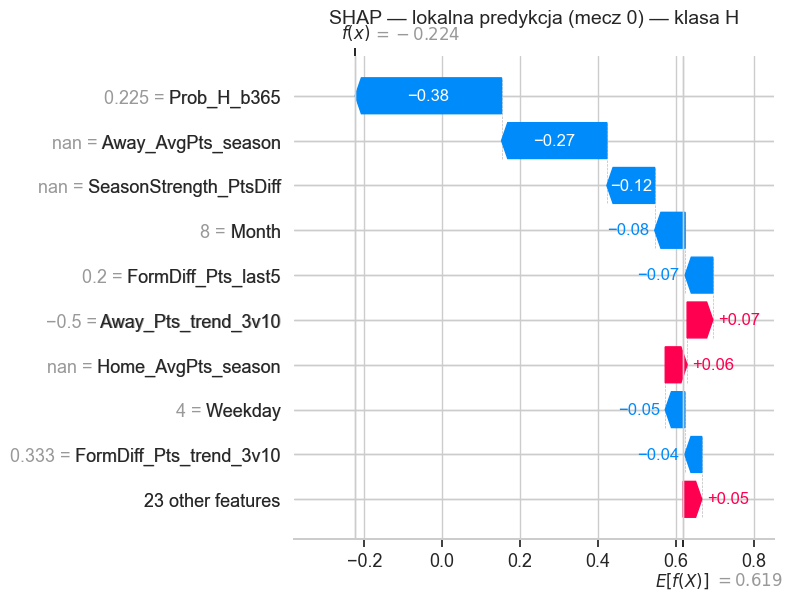

In [59]:

# SHAP — lokalne wyjaśnienie jednej obserwacji (klasa H)
idx = 0 
idx_H = list(le_xgb.classes_).index("H")

shap_exp = explainer(X_test.iloc[[idx]])
shap_exp_H = shap_exp[:, :, idx_H]

shap.plots.waterfall(
    shap_exp_H[0],
    show=False
)

plt.title(
    f"SHAP — lokalna predykcja (mecz {idx}) — klasa H",
    fontsize=14,
    y=1.05                   
)

plt.tight_layout(rect=[0, 0, 1, 0.95])  

save_plot(f"xgboost_shap_local_match_{idx}_H.png")
plt.show()
close_plot()



Model nie widzi tego meczu jako dobrego kandydata na Home Win,
głównie dlatego, że kursy bukmacherskie + forma punktowa silnie temu przeczą.